# Εξόρυξη και Ανάλυση Συναισθήματος με Χρήση BERT και RoBERTa σε Κείμενα από Διαδικτυακές Πλατφόρμες

## Sentiment Mining and Analysis using BERT and RoBERTa on Online Platform Texts

---

###  Thesis Overview

This thesis presents a comprehensive comparative analysis of emotion and sentiment detection in online community discussions using two state-of-the-art transformer-based models: **BERT** and **RoBERTa**. The study focuses on analyzing user interactions from Stack Overflow, one of the largest developer communities, to understand the emotional landscape of technical discussions.

---

###  Research Objectives

1. **Compare Performance**: Evaluate and compare the emotion detection capabilities of BERT and RoBERTa models on real-world text data
2. **Sentiment Analysis**: Map fine-grained emotions to broader sentiment categories (positive, negative, neutral)
3. **Statistical Validation**: Apply rigorous statistical tests to measure inter-model agreement and significance
4. **Correlation Analysis**: Investigate relationships between detected emotions and user engagement metrics (scores, votes, reputation)
5. **Geographical Insights**: Explore emotional patterns across different user locations

---

###  Dataset

The analysis utilizes three interconnected datasets from the Stack Overflow Data (BigQuery Dataset):

| Dataset | Description | Key Features |
|---------|-------------|--------------|
| `comments.csv` | User comments on posts | id,text, score, user_id, post_id |
| `posts_answers.csv` | Questions and answers | id, score, comment_count, favorite_count |
| `users.csv` | User metadata | id, display_name, age, reputation, location, up_votes, down_votes |

---

###  Models Used

| Model | Architecture | Source |
|-------|--------------|--------|
| **RoBERTa** | `SamLowe/roberta-base-go_emotions` | Hugging Face |
| **BERT** | `monologg/bert-base-cased-goemotions-original` | Hugging Face |

Both models are trained on the **Stack Overflow Data (BigQuery Dataset)** dataset, which classifies text into 28 fine-grained emotion categories.

---

###  Methodology
```
┌─────────────────────────────────────────────────────────────────┐
│  1. DATA LOADING & EXPLORATION                                  │
│     └── Load datasets, examine structure, identify patterns     │
├─────────────────────────────────────────────────────────────────┤
│  2. TEXT PREPROCESSING                                          │
│     └── Clean HTML, URLs, emojis; normalize text                │
├─────────────────────────────────────────────────────────────────┤
│  3. EXPLORATORY TEXT ANALYSIS                                   │
│     └── Word frequency, bigrams, trigrams                       │
├─────────────────────────────────────────────────────────────────┤
│  4. EMOTION INFERENCE                                           │
│     └── Apply BERT & RoBERTa models to classify emotions        │
├─────────────────────────────────────────────────────────────────┤
│  5. SENTIMENT MAPPING                                           │
│     └── Map 28 emotions → positive/negative/neutral             │
├─────────────────────────────────────────────────────────────────┤
│  6. STATISTICAL ANALYSIS                                        │
│     └── Cohen's Kappa, McNemar's Test, Correlations, T-tests    │
├─────────────────────────────────────────────────────────────────┤
│  7. COMPARATIVE VISUALIZATION                                   │
│     └── Charts, heatmaps, confusion matrices                    │
├─────────────────────────────────────────────────────────────────┤
│  8. INSIGHTS & CONCLUSIONS                                      │
│     └── Key findings, model recommendations                     │
└─────────────────────────────────────────────────────────────────┘
```

---

###  Statistical Tests Applied

- **Cohen's Kappa**: Measures inter-model agreement beyond chance
- **McNemar's Test**: Tests for systematic differences between models
- **Pearson & Spearman Correlation**: Analyzes relationships between confidence scores and engagement metrics
- **Independent T-test**: Compares confidence score distributions between models

---

###  Emotion Categories (GoEmotions Taxonomy)

| Positive | Negative | Neutral |
|----------|----------|---------|
| admiration, amusement, approval, caring, desire, excitement, gratitude, joy, love, optimism, pride, relief | anger, annoyance, disappointment, disapproval, disgust, embarrassment, fear, grief, nervousness, remorse, sadness | confusion, curiosity, neutral, realization, surprise |

---

### Technologies & Libraries

- **Programming Language**: Python 3.x
- **Deep Learning & NLP**: Transformers, PyTorch, NLTK
- **Data Science**: Pandas, NumPy, Scikit-learn, Statsmodels, SciPy
- **Visualization**: Seaborn, Matplotlib
- **Utilities**: Emoji, IPython, tqdm
- **Standard Libraries**: ast, re, os, warnings, collections, difflib

---

###  Author Information
- **Student Name**: Stergios Moutzikos
- **Student ID**: Inf2021149
- **Institution**: Ionian University
- **Department**: Informatics
- **Academic Year**: 2025-2026

---

## Required downloads

In [1]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Library imports and NLTK resource downloads

In [2]:
# IMPORT LIBRARIES
import pandas as pd # Διαχείριση δεδομένων σε πίνακες
import numpy as np 
import ast # Μετατροπή strings σε Python objects
import re # Καθαρισμός κειμένου, αφαίρεση URLs
import os 
import emoji
import warnings
from collections import Counter # Μέτρηση συχνοτήτων συναισθημάτων
from difflib import SequenceMatcher # Εύρεση παρόμοιων σχολίων

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# NLP & Text
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Transformers
from transformers import pipeline
import torch
import time

# Statistics
from scipy.stats import pearsonr, spearmanr, ttest_ind
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score

# Display
from IPython.display import display, HTML

# Progress Bar
from tqdm.notebook import tqdm

# DOWNLOAD NLTK RESOURCES
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Settings
tqdm.pandas()
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\steg1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\steg1\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\steg1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\steg1\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\steg1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Data Loading and Initial Data Exploration 

In [3]:
# LOAD DATA

comments = pd.read_csv("comments.csv")
posts_answers = pd.read_csv("posts_answers.csv")
users = pd.read_csv("users.csv")

warnings.filterwarnings('ignore')


In [4]:
# INITIAL EXPLORATION
print("Users shape:", users.shape)
print("Comments shape:", comments.shape)
print("Posts_answers shape:", posts_answers.shape)


Users shape: (54836, 7)
Comments shape: (110000, 5)
Posts_answers shape: (50853, 4)




--- Initial Exploration: Comments Data (Selected Columns) ---

Head of Selected Columns:


,text,post_id,user_id,score
0,Check out http://uRequire.org project that bri...,16522990,799502.0,7
1,"Or even simpler: Arrays.asList(1, 2, 3);",2607335,244360.0,125
2,@Juhana I was thinking maybe there was some wa...,18412129,912703.0,9
3,You just asked the same the question! http://s...,18415682,256196.0,5
4,Thank you. I also found that for just the purp...,18414263,1055817.0,12



Missing Values:


text          0
post_id       0
user_id    1078
score         0
dtype: int64

Duplicate Rows: 1
Unique Users: 54836
Unique Posts: 100818

Descriptive Statistics:


,score
count,110000.000000
mean,0.283300
std,2.809226
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,484.000000


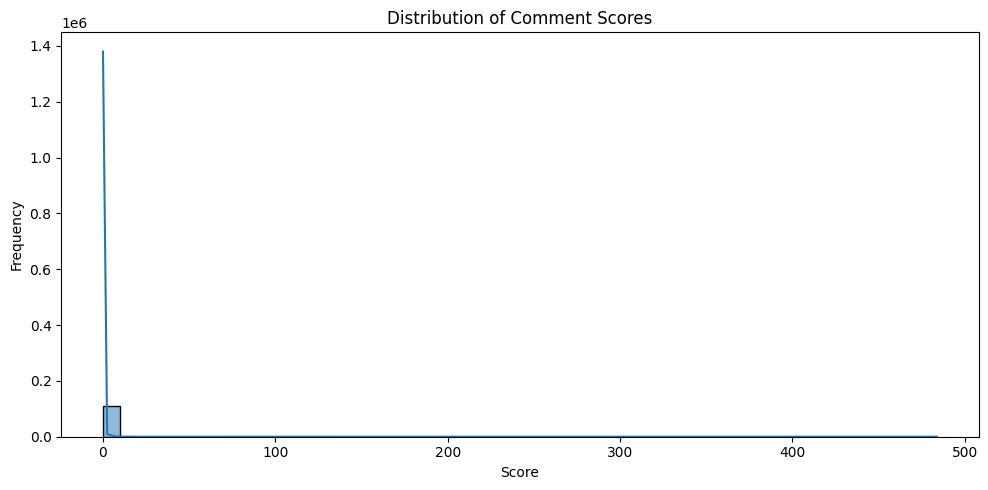

In [5]:
print("\n\n--- Initial Exploration: Comments Data (Selected Columns) ---")
# Select only the required columns

comments_selected = comments[["text", "post_id", "user_id", "score"]]

# Display first rows
print("\nHead of Selected Columns:")
display(comments_selected.head())

# Missing values
print("\nMissing Values:")
display(comments_selected.isnull().sum())

# Duplicate rows
print("Duplicate Rows:", comments_selected.duplicated().sum())

# Unique users and posts
print("Unique Users:", comments_selected["user_id"].nunique())
print("Unique Posts:", comments_selected["post_id"].nunique())

# Basic descriptive statistics (only numeric columns)
print("\nDescriptive Statistics:")
display(comments_selected[["score"]].describe())

# Visualization: Score distribution
plt.figure(figsize=(10,5))
sns.histplot(comments_selected["score"].dropna(), bins=50, kde=True)
plt.title("Distribution of Comment Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



--- Initial Exploration: Posts_answers (Selected Columns) ---

Head of Selected Columns:


,comment_count,favorite_count,score
0,1,NaN,0
1,1,NaN,0
2,1,NaN,0
3,1,NaN,1
4,1,NaN,1



Missing Values:


comment_count         0
favorite_count    50853
score                 0
dtype: int64

Duplicate Rows (excluding id): 48717

Descriptive Statistics:


,comment_count,favorite_count,score
count,50853.000000,0.0,50853.000000
mean,4.609561,NaN,10.407075
std,3.762111,NaN,89.020001
min,1.000000,NaN,-27.000000
25%,2.000000,NaN,0.000000
50%,4.000000,NaN,1.000000
75%,6.000000,NaN,3.000000
max,88.000000,NaN,5741.000000


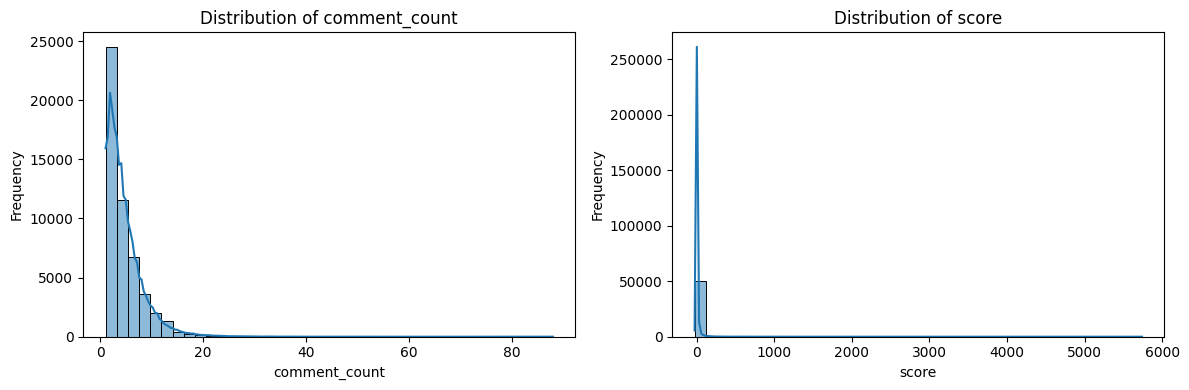

In [6]:
print("\n\n--- Initial Exploration: Posts_answers (Selected Columns) ---")

selected_cols = ["comment_count", "favorite_count", "score"]
posts_selected = posts_answers[selected_cols]

# Display first rows
print("\nHead of Selected Columns:")
display(posts_selected.head())

# Missing values
print("\nMissing Values:")
display(posts_selected.isnull().sum())

# Duplicate rows (excluding id):
print("Duplicate Rows (excluding id):", posts_selected.duplicated().sum())

# Basic descriptive statistics
print("\nDescriptive Statistics:")
display(posts_selected.describe())

# Visualizations (comment_count and score only)
plt.figure(figsize=(12, 4))
plot_cols = ["comment_count", "score"]
for idx, col in enumerate(plot_cols, 1):
    plt.subplot(1, 2, idx)
    sns.histplot(posts_answers[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()




--- User Distributions: Reputation, Up Votes, Down Votes ---

Head of Selected Columns:


,age,location,reputation,up_votes,down_votes
0,NaN,Switzerland,313331,8360,216
1,NaN,"London, United Kingdom",43384,370,27
2,NaN,Argentina,1828,140,31
3,NaN,"Minneapolis, MN, United States",1558,1339,186
4,NaN,United Kingdom,31332,3450,334



Missing Values:


age           54836
location      25336
reputation        0
up_votes          0
down_votes        0
dtype: int64

Duplicate Rows: 8215

Descriptive Statistics:


,age,reputation,up_votes,down_votes
count,0,"54,836","54,836","54,836"
mean,NaN,"8,499",543,162
std,NaN,"34,087","1,493","1,889"
min,NaN,1,0,0
25%,NaN,204,11,0
50%,NaN,"1,244",90,3
75%,NaN,"5,106",450,20
max,NaN,"1,357,603","66,690","153,599"


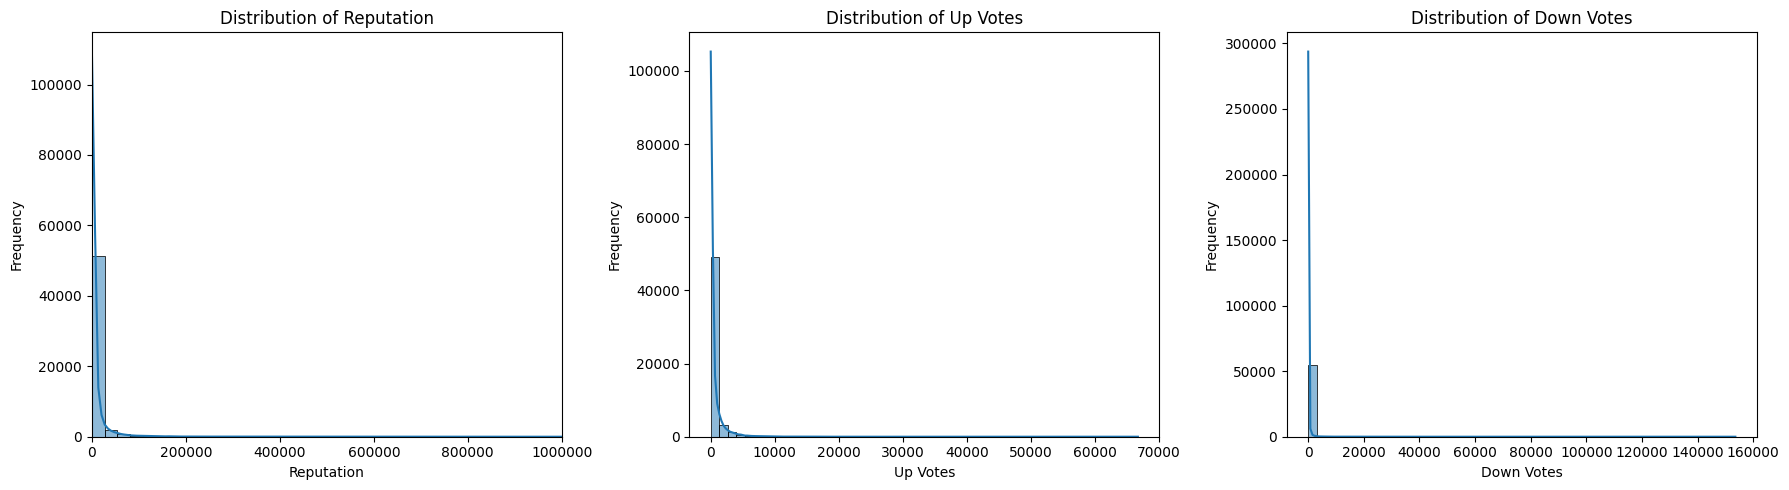


Top 10 User Locations:


location
India                     774
Germany                   589
United States             525
London, United Kingdom    507
United Kingdom            423
Bangalore, India          321
Netherlands               308
Berlin, Germany           273
France                    252
Paris, France             233
Name: count, dtype: int64

In [7]:
# Disable scientific notation globally
pd.options.display.float_format = '{:,.0f}'.format
print("\n\n--- User Distributions: Reputation, Up Votes, Down Votes ---")
users_selected = users[["age", "location", "reputation", "up_votes", "down_votes"]]

# Head
print("\nHead of Selected Columns:")
display(users_selected.head())

# Missing values
print("\nMissing Values:")
display(users_selected.isnull().sum())

# Duplicate rows
print("Duplicate Rows:", users_selected.duplicated().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
display(users_selected[["age", "reputation", "up_votes", "down_votes"]].describe())

# Histograms with KDE lines
plt.figure(figsize=(18, 5))
cols_to_plot = ["reputation", "up_votes", "down_votes"]
for idx, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, idx)

    # Histogram with KDE
    sns.histplot(users_selected[col].dropna(), bins=50, kde=True)

    # Cap reputation if desired
    if col == "reputation":
        plt.xlim(0, 1_000_000)

    # Real numbers on x-axis
    plt.ticklabel_format(style='plain', axis='x')

    plt.title(f"Distribution of {col.replace('_',' ').title()}")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Top 10 user locations
print("\nTop 10 User Locations:")
display(users_selected["location"].value_counts().head(10))




## Text Cleaning Utilities and Application

In [8]:
# TEXT CLEANING UTILITIES


# Regex Patterns
URL_PATTERN = re.compile(r"http\S+|www.\S+")
MEANINGFUL_TEXT_PATTERN = re.compile(r"\w{3,}")
EMOJI_PATTERN = re.compile("[\U0001F600-\U0001F64F"
                           "\U0001F300-\U0001F5FF"
                           "\U0001F680-\U0001F6FF"
                           "\U0001F1E0-\U0001F1FF]+", flags=re.UNICODE)


In [9]:
def has_meaningful_text(text):
    text = URL_PATTERN.sub("", text)
    return bool(MEANINGFUL_TEXT_PATTERN.search(text))

def remove_emojis(text):
    return emoji.replace_emoji(text, replace="")

def clean_text(text, lower=True, strip=True, remove_urls=True, remove_emojis_flag=True):
    if pd.isna(text):
        return ""

    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
        
    if lower:
        text = text.lower()
    if remove_urls:
        text = URL_PATTERN.sub("", text)
    if remove_emojis_flag:
        text = remove_emojis(text)
    if strip:
        text = text.strip()
    return text

In [10]:
def clean_comments(df, text_col="text", min_words=3, drop_duplicates=True, remove_emojis_flag=True, lower=True):
    df = df.copy()
    df = df[df[text_col].notna()]
    df = df[df[text_col].str.strip() != ""]
    df[text_col] = df[text_col].apply(lambda x: clean_text(x, lower=lower, remove_emojis_flag=remove_emojis_flag))
    if drop_duplicates:
        df = df.drop_duplicates(subset=[text_col])
    df = df[df[text_col].str.split().str.len() >= min_words]
    df = df[df[text_col].apply(has_meaningful_text)]
    return df.reset_index(drop=True)




In [11]:
comments_original_count = len(comments)

In [12]:
# Apply cleaning
comments = clean_comments(comments, min_words=3, remove_emojis_flag=True)

In [13]:
print(f"\n--- Cleaning Summary ---")
print(f"Before cleaning: {comments_original_count} rows")
print(f"After cleaning: {len(comments)} rows")
print(f"Removed: {comments_original_count - len(comments)} rows ({(comments_original_count - len(comments)) / comments_original_count * 100:.1f}%)")


--- Cleaning Summary ---
Before cleaning: 110000 rows
After cleaning: 108687 rows
Removed: 1313 rows (1.2%)


In [14]:
# Sample validation
print("\n--- Sample Cleaned Comments ---")
print("Showing 5 random cleaned comments to verify quality:\n")
for i, text in enumerate(comments["text"].sample(5, random_state=42).values, 1):
    print(f"{i}. {text[:150]}{'...' if len(text) > 150 else ''}\n")


--- Sample Cleaned Comments ---
Showing 5 random cleaned comments to verify quality:

1. @lundin - edited (with more readable option), however, the intent of the answer was to show a one-liner, and to show other, simpler possibilities.  i ...

2. did you compile this as c or c++?  it should be complaining about the use of `instruction` without an accompanying `struct` keyword.  your typdef name...

3. @edhedges interesting read

4. @danielgonzalez thanks for your answer; i copied the login.html page from server/conf to myapp/common; i do not have a loginerror.html. where should i...

5. what's the benefit of copying it to another variable?



## Basic Text Statistics and Word Frequency Analysis


In [15]:
# BASIC STATS & VISUALS
print("Number of comments:", len(comments))
print("Unique users:", comments["user_id"].nunique())
print("Missing values in text:", comments["text"].isna().sum())



Number of comments: 108687
Unique users: 54486
Missing values in text: 0


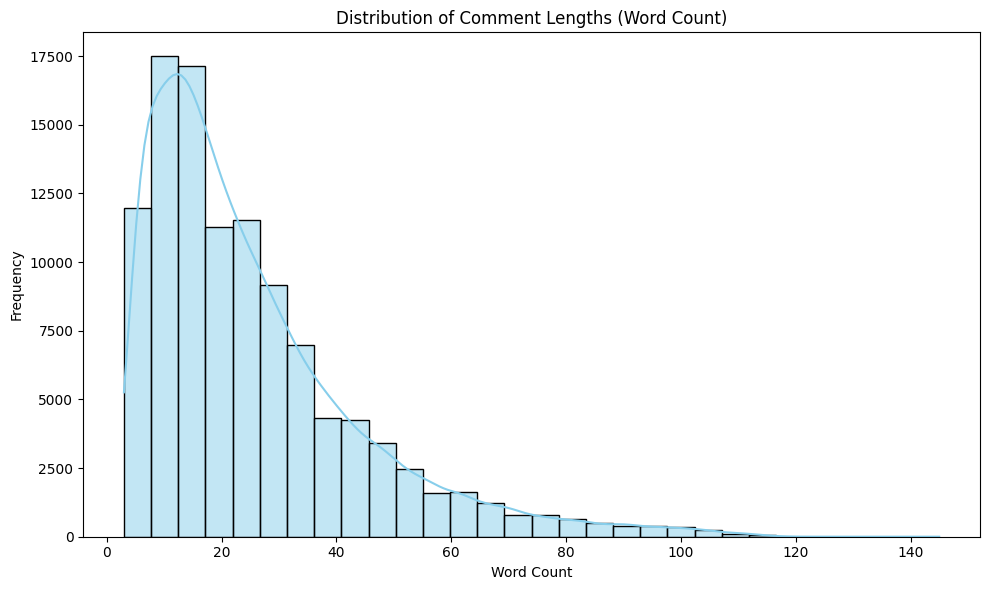

In [16]:
# Word Count Distribution
comments["word_count"] = comments["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(comments["word_count"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Comment Lengths (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

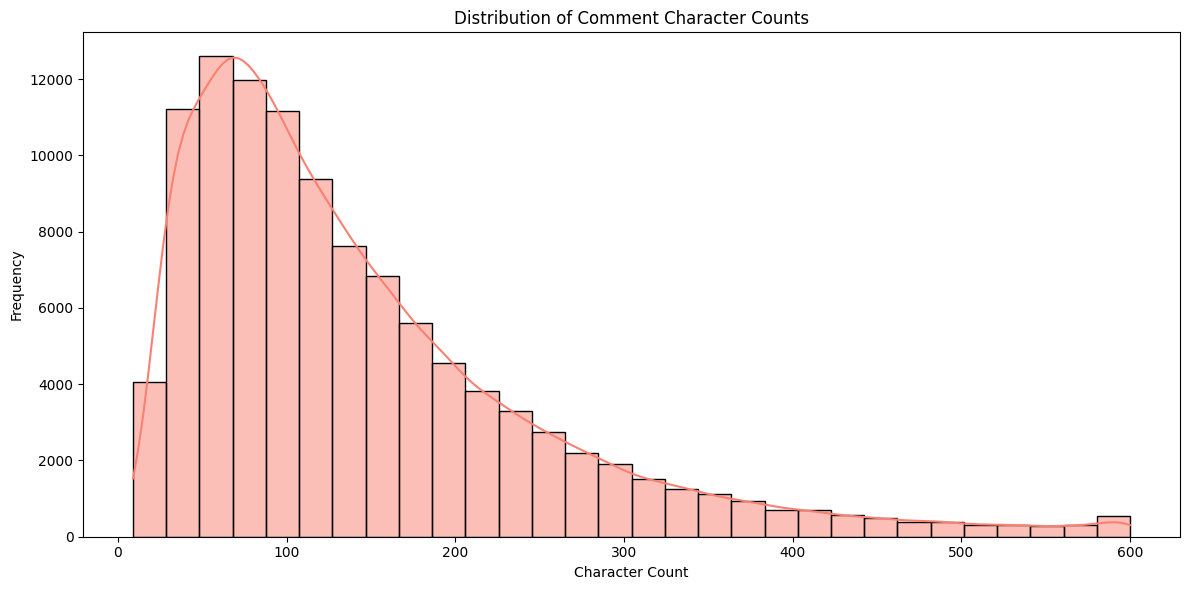

In [17]:
# Character count
comments["char_count"] = comments["text"].apply(lambda x: len(str(x)))

plt.figure(figsize=(12, 6))
sns.histplot(comments["char_count"], bins=30, kde=True, color="salmon")
plt.title("Distribution of Comment Character Counts")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



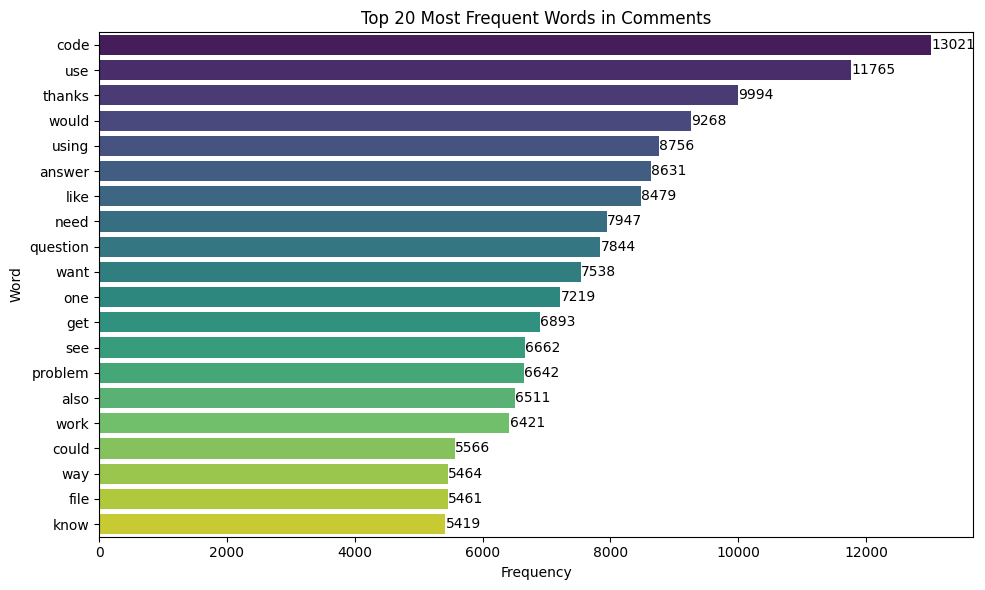

In [18]:
# WORD FREQUENCY ANALYSIS

stop_words = set(stopwords.words("english"))

def tokenize(text):
    tokens = word_tokenize(str(text).lower())
    return [word for word in tokens if word not in stop_words and word.isalpha() and len(word) > 2]

all_words = sum(comments["text"].apply(tokenize).tolist(), [])
top_words = Counter(all_words).most_common(20)

# Plot Top Words
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Most Frequent Words in Comments")
plt.xlabel("Frequency")
plt.ylabel("Word")

for i, count in enumerate(counts):
    ax.text(count + 0.5, i, str(count), va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Tokenization & N-gram Analysis (Bigrams & Trigrams)

In [19]:

# Unified preprocessing function 
def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]
    return tokens

# Apply to comments
comments['tokens'] = comments['text'].progress_apply(preprocess_text)

# Generate bigrams
bigrams_list = []
for tokens in comments['tokens']:
    bigrams_list.extend(list(nltk.bigrams(tokens)))

# Count top bigrams
bigram_counts = Counter(bigrams_list)
top_bigrams = bigram_counts.most_common(20)

  0%|          | 0/108687 [00:00<?, ?it/s]

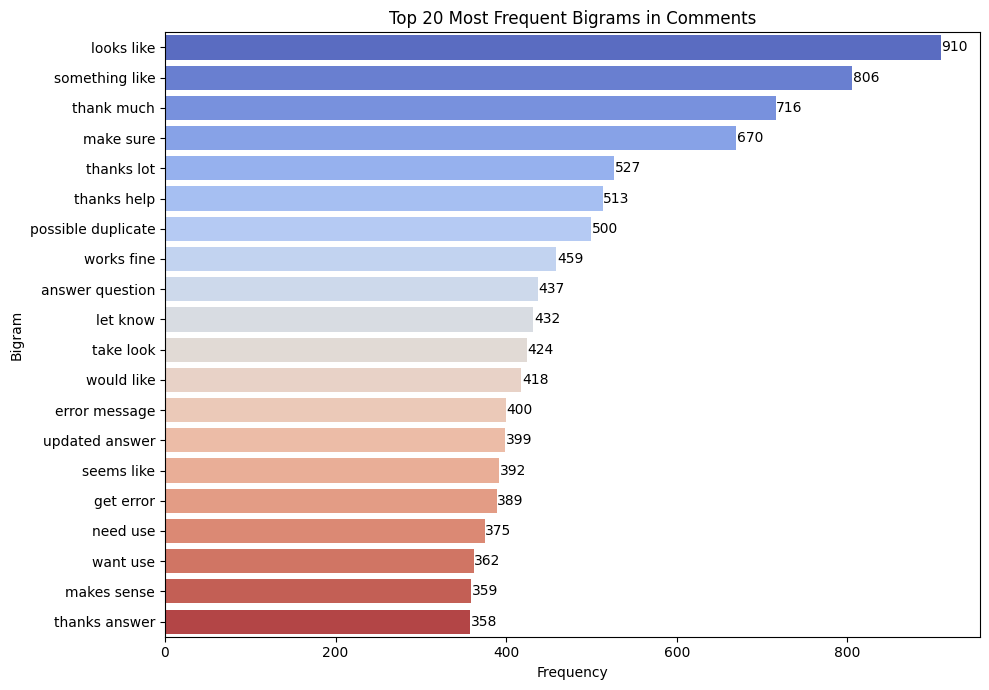

In [20]:
# Plot Top Bigrams
bigram_words = [" ".join(bg) for bg, count in top_bigrams]
bigram_counts_val = [count for bg, count in top_bigrams]

plt.figure(figsize=(10, 7))
ax = sns.barplot(x=bigram_counts_val, y=bigram_words, palette="coolwarm")
plt.title("Top 20 Most Frequent Bigrams in Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
for i, count in enumerate(bigram_counts_val):
    ax.text(count + 0.5, i, str(count), va='center', fontsize=10)
plt.tight_layout()
plt.show()

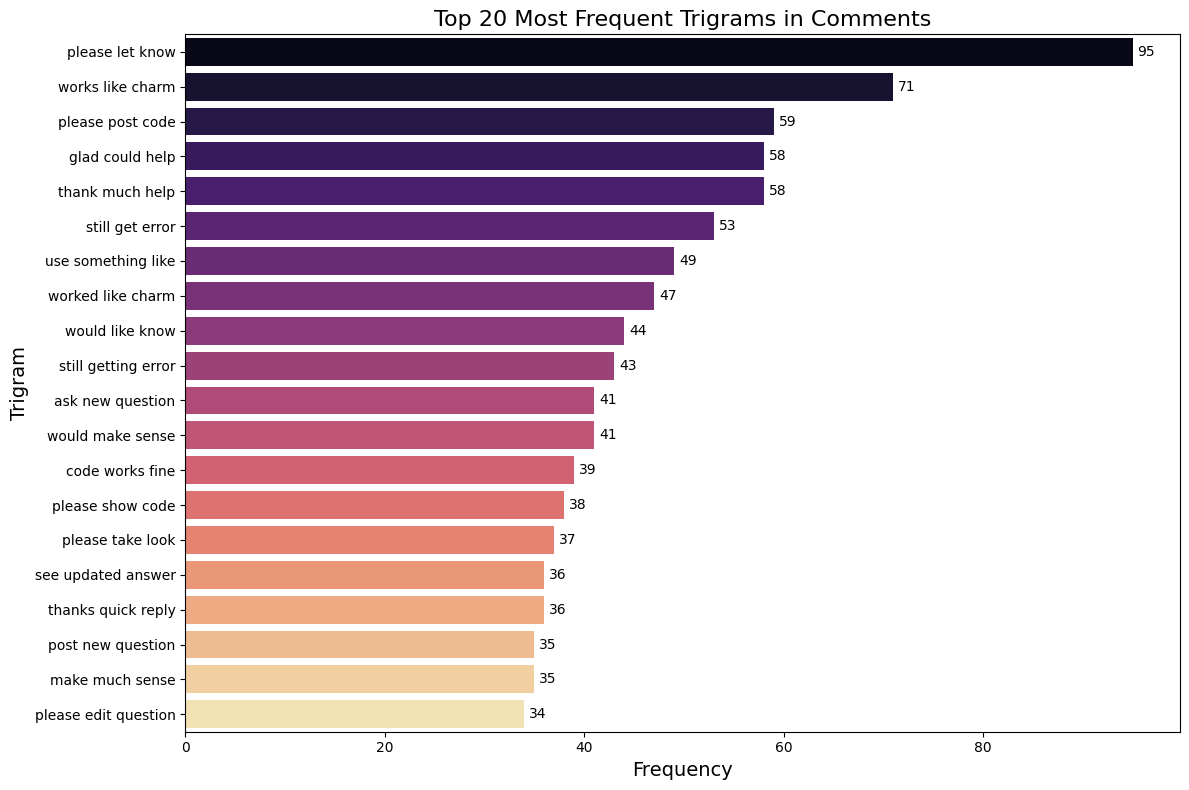

In [21]:
# Generate trigrams 
trigrams_list = []
for tokens in comments['tokens']:
    trigrams_list.extend(list(nltk.trigrams(tokens)))

# Count top trigrams 
trigram_counts = Counter(trigrams_list)
top_trigrams = trigram_counts.most_common(20)

# Plot Top Trigrams 
trigram_words = [" ".join(tg) for tg, count in top_trigrams]
trigram_counts_val = [count for tg, count in top_trigrams]

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=trigram_counts_val, y=trigram_words, palette="magma")
plt.title(f"Top 20 Most Frequent Trigrams in Comments", fontsize=16)
plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Trigram", fontsize=14)
for i, count in enumerate(trigram_counts_val):
    ax.text(count + 0.5, i, f"{count}", va='center', fontsize=10)
plt.tight_layout()
plt.show()



## Emotion Inference with RobERTa and BERT

In [22]:

# Check GPU availability
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU (CUDA)' if device == 0 else 'CPU'}")

Using device: CPU


In [23]:
# RoBERTa GoEmotions 
def run_roberta_goemotions(df, text_col="text", batch_size=16):
    classifier = pipeline(
        "text-classification",
        model="SamLowe/roberta-base-go_emotions",
        top_k=None,
        device=device,
        truncation=True
    )
    texts = [str(t)[:512] for t in df[text_col].tolist()]
    
    top_labels = []
    top_scores = []
    all_outputs = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Running RoBERTa GoEmotions"):
        batch = texts[i:i+batch_size]
        batch_results = classifier(batch)
        
        for result in batch_results:
            sorted_result = sorted(result, key=lambda x: x["score"], reverse=True)
            top_labels.append(sorted_result[0]["label"])
            top_scores.append(sorted_result[0]["score"])
            all_outputs.append({r["label"]: r["score"] for r in sorted_result})
    
    df["roberta_top_emotion"] = top_labels
    df["roberta_emotion_score"] = top_scores
    df["roberta_all_emotions"] = all_outputs
    return df


In [24]:
# BERT GoEmotions
def run_bert_goemotions(df, text_col="text", batch_size=16):
    classifier = pipeline(
        "text-classification",
        model="monologg/bert-base-cased-goemotions-original",
        top_k=None,
        device=device,
        truncation=True
    )
    texts = [str(t)[:512] for t in df[text_col].tolist()]
    
    top_labels = []
    top_scores = []
    all_outputs = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Running BERT GoEmotions"):
        batch = texts[i:i+batch_size]
        batch_results = classifier(batch)
        
        for result in batch_results:
            sorted_result = sorted(result, key=lambda x: x["score"], reverse=True)
            top_labels.append(sorted_result[0]["label"])
            top_scores.append(sorted_result[0]["score"])
            all_outputs.append({r["label"]: r["score"] for r in sorted_result})
    
    df["bert_top_emotion"] = top_labels
    df["bert_emotion_score"] = top_scores
    df["bert_all_emotions"] = all_outputs
    return df

In [25]:
# RUN RoBERTa 
print("Running RoBERTa GoEmotions...")
start_time = time.time()
comments = run_roberta_goemotions(comments)
print(f"---> RoBERTa completed in {time.time() - start_time:.2f} seconds.")

Running RoBERTa GoEmotions...


Device set to use cpu


Running RoBERTa GoEmotions:   0%|          | 0/6793 [00:00<?, ?it/s]

---> RoBERTa completed in 3224.99 seconds.


In [26]:
# RUN BERT 
print("Running BERT GoEmotions...")
start_time = time.time()
comments = run_bert_goemotions(comments)
print(f"---> BERT completed in {time.time() - start_time:.2f} seconds.")

Running BERT GoEmotions...


Device set to use cpu


Running BERT GoEmotions:   0%|          | 0/6793 [00:00<?, ?it/s]

---> BERT completed in 2895.66 seconds.


In [27]:
# SAVE RESULTS
comments.to_csv("comments_with_emotions.csv", index=False)
print("Saved → comments_with_emotions.csv")

Saved → comments_with_emotions.csv


In [28]:
# QUICK COMPARISON 
print("Quick Model Comparison \n")

print("RoBERTa top 5 emotions:")
print(comments["roberta_top_emotion"].value_counts().head())
print("\nBERT top 5 emotions:")
print(comments["bert_top_emotion"].value_counts().head())



Quick Model Comparison 

RoBERTa top 5 emotions:
roberta_top_emotion
neutral      60841
gratitude    13119
curiosity    11305
confusion     7140
approval      5215
Name: count, dtype: int64

BERT top 5 emotions:
bert_top_emotion
neutral      61655
gratitude    12814
curiosity    10014
confusion     7272
approval      4486
Name: count, dtype: int64


## Load, Merge, and Map Data to Sentiments

In [1]:
# LOAD & MERGE ALL DATA 
comments = pd.read_csv("comments_with_emotions.csv")
users = pd.read_csv("users.csv")
posts = pd.read_csv("posts_answers.csv")

# Parse dictionary columns
def safe_parse(x):
    if pd.isna(x): # if none return empty dictionary
        return {}
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return {}

comments["roberta_all_emotions"] = comments["roberta_all_emotions"].apply(safe_parse)
comments["bert_all_emotions"] = comments["bert_all_emotions"].apply(safe_parse)

# Merge with users (INCLUDING LOCATION)
df = comments.merge(
    users[["id", "location", "reputation", "up_votes", "down_votes"]],
    left_on="user_id",
    right_on="id",
    how="left",
    suffixes=('', '_user')
)

# Merge with posts
df = df.merge(
    posts[["id", "score", "comment_count", "favorite_count"]],
    left_on="post_id",
    right_on="id",
    how="left",
    suffixes=('', '_post')
)

print(f"Loaded {len(comments)} comments")
print(f"Merged dataset shape: {df.shape}")

NameError: name 'pd' is not defined

In [30]:
# EMOTION TO SENTIMENT MAPPING
# GoEmotions has 28 emotions 

EMOTION_TO_SENTIMENT = {
    # Positive emotions
    "admiration": "positive",
    "amusement": "positive",
    "approval": "positive",
    "caring": "positive",
    "desire": "positive",
    "excitement": "positive",
    "gratitude": "positive",
    "joy": "positive",
    "love": "positive",
    "optimism": "positive",
    "pride": "positive",
    "relief": "positive",
    
    # Negative emotions
    "anger": "negative",
    "annoyance": "negative",
    "disappointment": "negative",
    "disapproval": "negative",
    "disgust": "negative",
    "embarrassment": "negative",
    "fear": "negative",
    "grief": "negative",
    "nervousness": "negative",
    "remorse": "negative",
    "sadness": "negative",
    
    # Neutral emotions
    "confusion": "neutral",
    "curiosity": "neutral",
    "neutral": "neutral",
    "realization": "neutral",
    "surprise": "neutral"
}

# Apply sentiment mapping
comments["roberta_sentiment"] = comments["roberta_top_emotion"].map(EMOTION_TO_SENTIMENT)
comments["bert_sentiment"] = comments["bert_top_emotion"].map(EMOTION_TO_SENTIMENT)

print("Sentiment mapping applied.")
print(f"\nRoBERTa sentiment distribution:\n{comments['roberta_sentiment'].value_counts()}")
print(f"\nBERT sentiment distribution:\n{comments['bert_sentiment'].value_counts()}")

Sentiment mapping applied.

RoBERTa sentiment distribution:
roberta_sentiment
neutral     80144
positive    22106
negative     6437
Name: count, dtype: int64

BERT sentiment distribution:
bert_sentiment
neutral     80427
positive    22010
negative     6250
Name: count, dtype: int64


## Model Agreement Analysis

In [31]:
# MODEL AGREEMENT ANALYSIS

# Exact emotion agreement
emotion_agreement = (comments["roberta_top_emotion"] == comments["bert_top_emotion"]).mean()
print(f"Exact Emotion Agreement: {emotion_agreement:.2%}")

# Sentiment agreement (positive/negative/neutral)
sentiment_agreement = (comments["roberta_sentiment"] == comments["bert_sentiment"]).mean()
print(f"Sentiment Agreement: {sentiment_agreement:.2%}")

# Create agreement column
comments["models_agree_emotion"] = comments["roberta_top_emotion"] == comments["bert_top_emotion"]
comments["models_agree_sentiment"] = comments["roberta_sentiment"] == comments["bert_sentiment"]

# Where do they disagree?
disagreements = comments[~comments["models_agree_emotion"]][["text", "roberta_top_emotion", "bert_top_emotion", "roberta_sentiment", "bert_sentiment"]]
print(f"\nNumber of disagreements: {len(disagreements)} ({len(disagreements)/len(comments)*100:.1f}%)")
print("\nSample disagreements:")
display(disagreements.head(10))

Exact Emotion Agreement: 78.45%
Sentiment Agreement: 90.40%

Number of disagreements: 23425 (21.6%)

Sample disagreements:


,text,roberta_top_emotion,bert_top_emotion,roberta_sentiment,bert_sentiment
2,@juhana i was thinking maybe there was some wa...,neutral,confusion,neutral,neutral
6,"nice, so `a = list(set(a))` gets the unique it...",admiration,approval,positive,positive
7,"i can't read your image, but i found this:",neutral,realization,neutral,neutral
9,"if you don't trust your friends, best to not g...",neutral,approval,neutral,positive
15,it is not working today. i can't find platform...,disapproval,neutral,negative,neutral
21,"main problem : when you close it, all applicat...",neutral,disappointment,neutral,negative
28,how would you pass `object` from command line?...,curiosity,neutral,neutral,neutral
33,you've come to the right site if you're gettin...,neutral,approval,neutral,positive
34,still 4 months to christmas,neutral,surprise,neutral,neutral
37,"sorry, i saw the mac os, and i thought you wer...",remorse,neutral,negative,neutral


##  Emotion and Sentiment Distribution Comparison

In [32]:
# EMOTION DISTRIBUTION COMPARISON

# Get value counts for both models
roberta_emotions = comments["roberta_top_emotion"].value_counts()
bert_emotions = comments["bert_top_emotion"].value_counts()

# Create comparison dataframe
emotion_comparison = pd.DataFrame({
    "RoBERTa": roberta_emotions,
    "BERT": bert_emotions
}).fillna(0).astype(int)

emotion_comparison["Difference"] = emotion_comparison["RoBERTa"] - emotion_comparison["BERT"]
emotion_comparison = emotion_comparison.sort_values("RoBERTa", ascending=False)

print("--- Emotion Distribution Comparison ---")
display(emotion_comparison)

--- Emotion Distribution Comparison ---


,RoBERTa,BERT,Difference
neutral,60841,61655,-814
gratitude,13119,12814,305
curiosity,11305,10014,1291
confusion,7140,7272,-132
approval,5215,4486,729
disapproval,2681,2259,422
remorse,1929,1535,394
admiration,1258,1797,-539
disappointment,1138,1159,-21
optimism,772,1314,-542


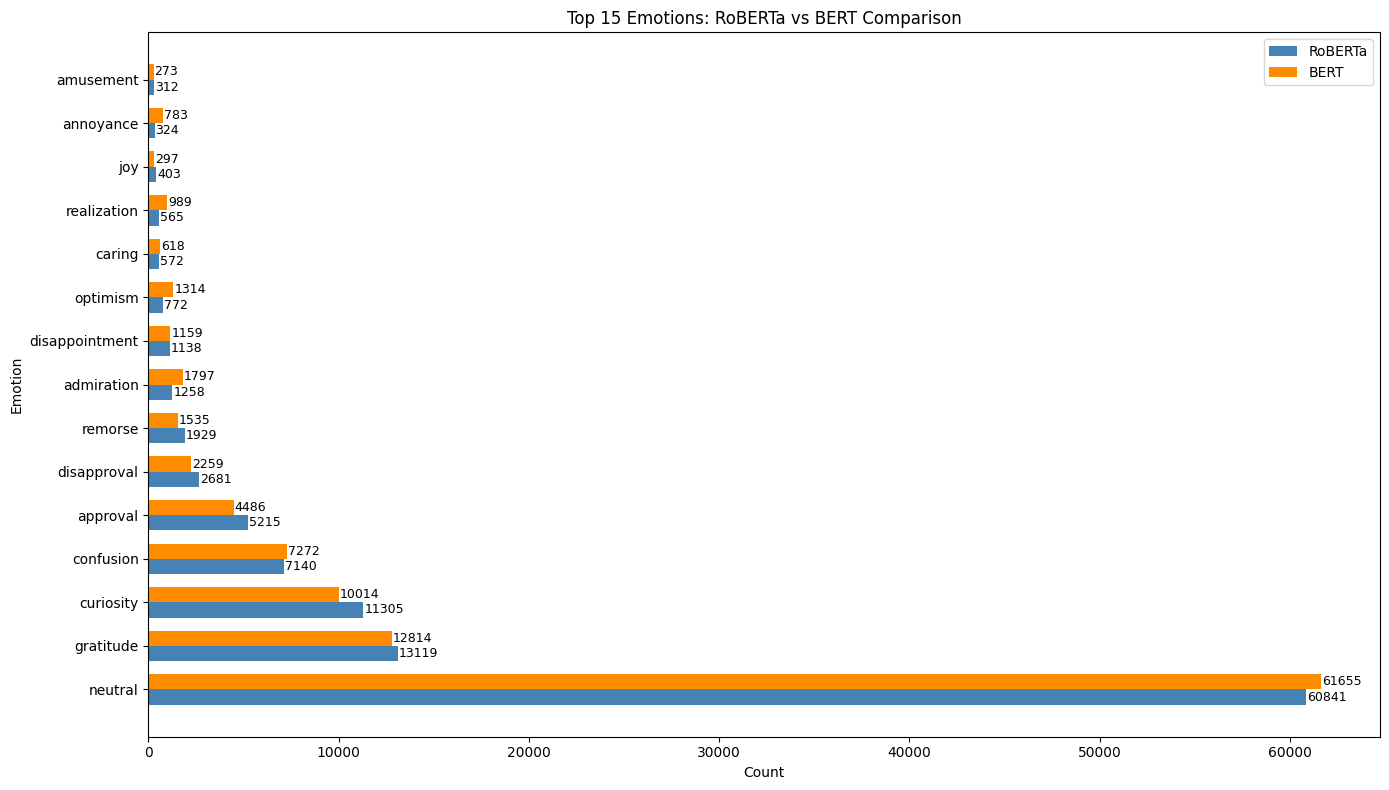

In [33]:
# SIDE-BY-SIDE EMOTION BAR CHART

# Get top 15 emotions (combined from both models)
top_emotions = emotion_comparison.head(15)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_emotions))
width = 0.35

bars1 = ax.barh(x - width/2, top_emotions["RoBERTa"], width, label="RoBERTa", color="steelblue")
bars2 = ax.barh(x + width/2, top_emotions["BERT"], width, label="BERT", color="darkorange")

ax.set_xlabel("Count")
ax.set_ylabel("Emotion")
ax.set_title("Top 15 Emotions: RoBERTa vs BERT Comparison")
ax.set_yticks(x)
ax.set_yticklabels(top_emotions.index)
ax.legend()

# Add value labels
for bar in bars1:
    width_val = bar.get_width()
    ax.text(width_val + 50, bar.get_y() + bar.get_height()/2, f'{int(width_val)}', va='center', fontsize=9)

for bar in bars2:
    width_val = bar.get_width()
    ax.text(width_val + 50, bar.get_y() + bar.get_height()/2, f'{int(width_val)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

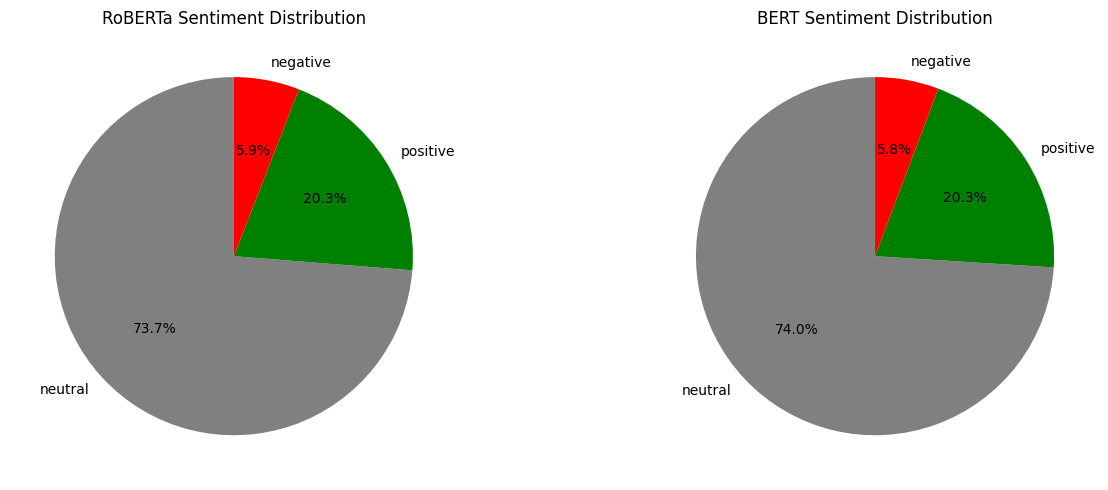

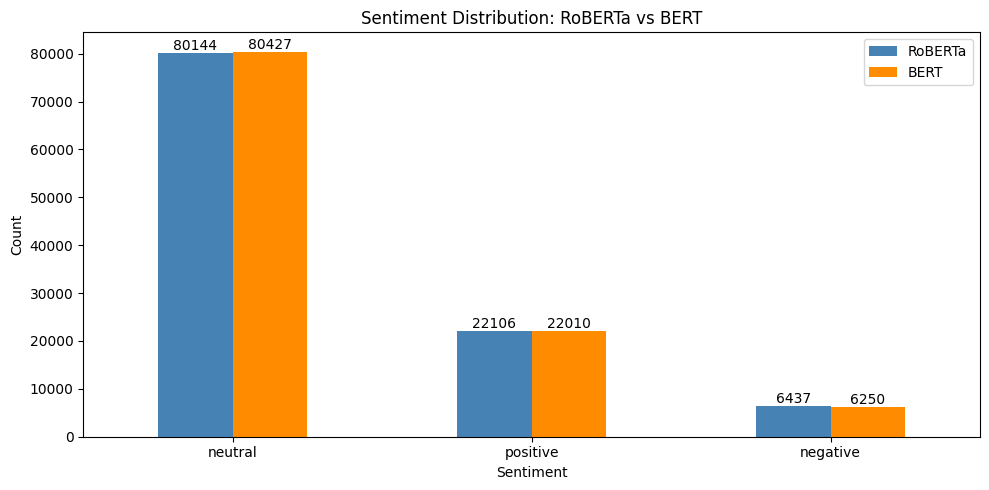

In [34]:
# SENTIMENT DISTRIBUTION COMPARISON

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RoBERTa sentiment
roberta_sent_counts = comments["roberta_sentiment"].value_counts()
colors = {"positive": "green", "negative": "red", "neutral": "gray"}
roberta_colors = [colors[s] for s in roberta_sent_counts.index]

axes[0].pie(roberta_sent_counts, labels=roberta_sent_counts.index, autopct='%1.1f%%', colors=roberta_colors, startangle=90)
axes[0].set_title("RoBERTa Sentiment Distribution")

# BERT sentiment
bert_sent_counts = comments["bert_sentiment"].value_counts()
bert_colors = [colors[s] for s in bert_sent_counts.index]

axes[1].pie(bert_sent_counts, labels=bert_sent_counts.index, autopct='%1.1f%%', colors=bert_colors, startangle=90)
axes[1].set_title("BERT Sentiment Distribution")

plt.tight_layout()
plt.show()

# Also show as bar chart
fig, ax = plt.subplots(figsize=(10, 5))

sentiment_comp = pd.DataFrame({
    "RoBERTa": roberta_sent_counts,
    "BERT": bert_sent_counts
}).fillna(0)

sentiment_comp.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Sentiment Distribution: RoBERTa vs BERT")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

## Confusion Matrix and Score Correlation

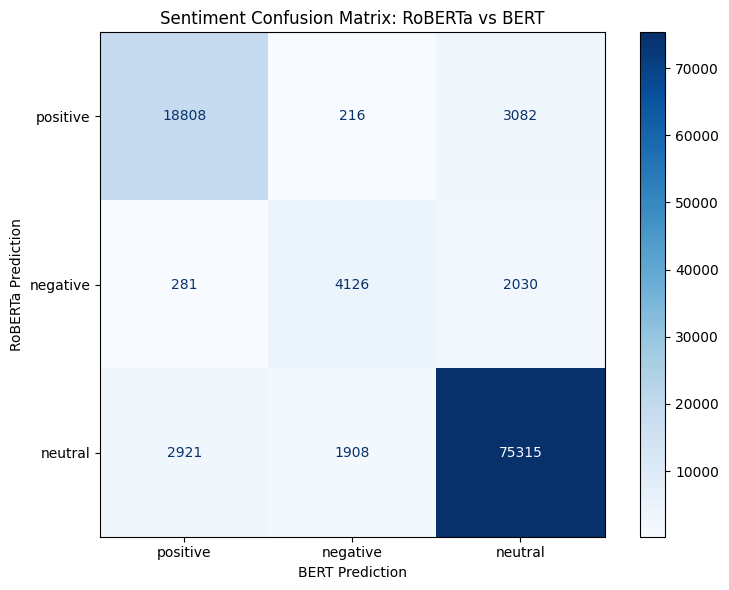

In [35]:
# CONFUSION MATRIX BETWEEN MODELS 

# Sentiment confusion matrix
sentiment_labels = ["positive", "negative", "neutral"]
cm_sentiment = confusion_matrix(
    comments["roberta_sentiment"], 
    comments["bert_sentiment"], 
    labels=sentiment_labels
)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sentiment, display_labels=sentiment_labels)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Sentiment Confusion Matrix: RoBERTa vs BERT")
ax.set_xlabel("BERT Prediction")
ax.set_ylabel("RoBERTa Prediction")
plt.tight_layout()
plt.show()

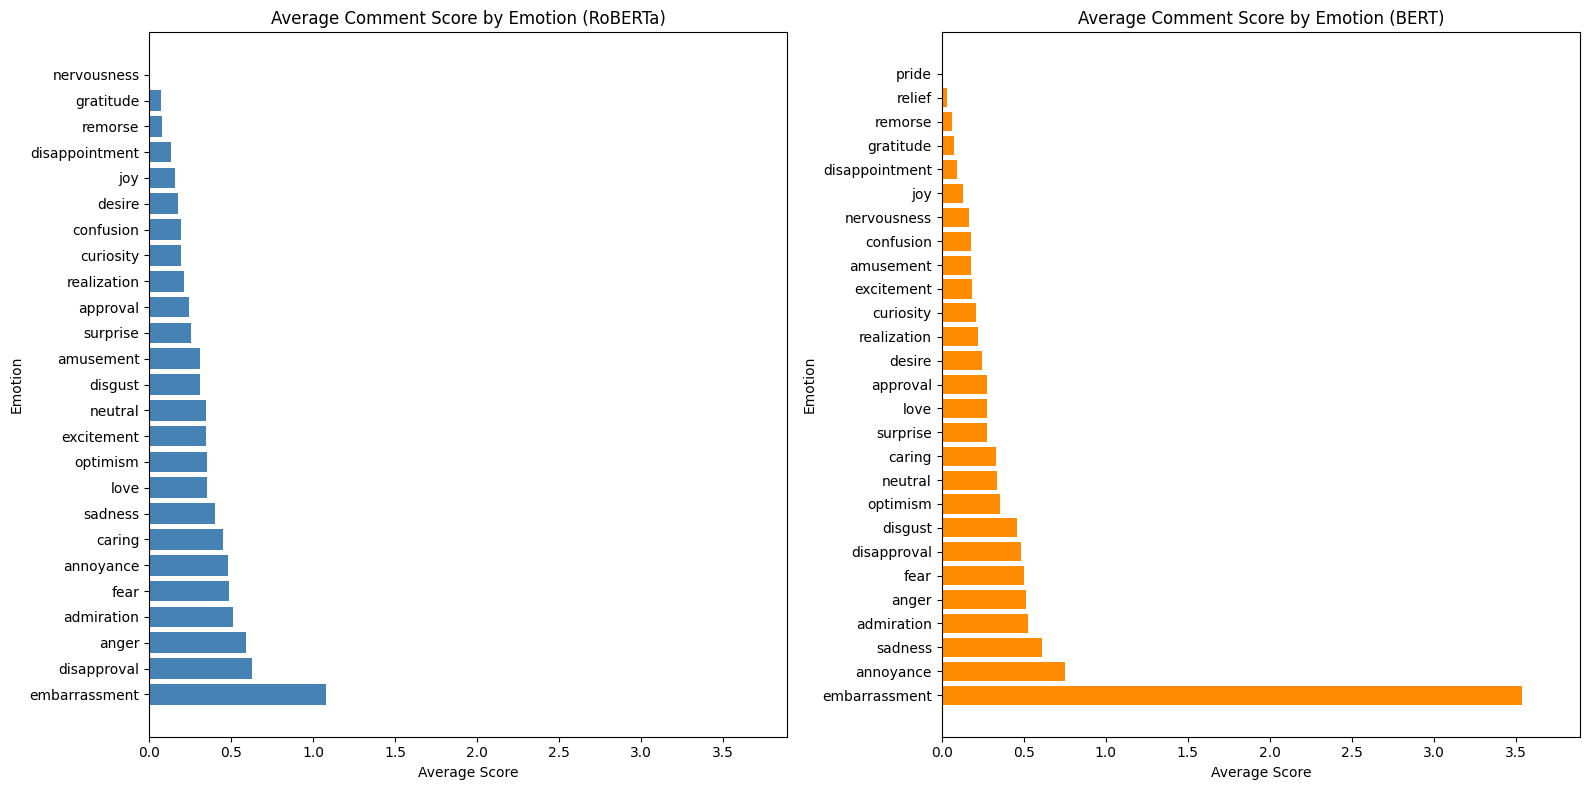

In [36]:
# EMOTION VS COMMENT SCORE CORRELATION 

# Average COMMENT score per emotion (NOT confidence score)
roberta_score_by_emotion = comments.groupby("roberta_top_emotion")["score"].mean().sort_values(ascending=False)
bert_score_by_emotion = comments.groupby("bert_top_emotion")["score"].mean().sort_values(ascending=False)

# Find common x-axis range for fair comparison
max_score = max(roberta_score_by_emotion.max(), bert_score_by_emotion.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# RoBERTa
axes[0].barh(roberta_score_by_emotion.index, roberta_score_by_emotion.values, color="steelblue")
axes[0].set_title("Average Comment Score by Emotion (RoBERTa)")
axes[0].set_xlabel("Average Score")
axes[0].set_ylabel("Emotion")
axes[0].set_xlim(0, max_score * 1.1)  # Same scale for both

# BERT
axes[1].barh(bert_score_by_emotion.index, bert_score_by_emotion.values, color="darkorange")
axes[1].set_title("Average Comment Score by Emotion (BERT)")
axes[1].set_xlabel("Average Score")
axes[1].set_ylabel("Emotion")
axes[1].set_xlim(0, max_score * 1.1)  # Same scale for both

plt.tight_layout()
plt.show()

In [37]:
# SAVE PROCESSED DATA 
comments.to_csv("comments_emotions_processed.csv", index=False)
print("Saved processed data → comments_emotions_processed.csv")

# Summary statistics
print("\n--- Final Summary ---")
print(f"Total comments analyzed: {len(comments)}")
print(f"Emotion agreement rate: {emotion_agreement:.2%}")
print(f"Sentiment agreement rate: {sentiment_agreement:.2%}")
print(f"RoBERTa avg confidence: {comments['roberta_emotion_score'].mean():.4f}")
print(f"BERT avg confidence: {comments['bert_emotion_score'].mean():.4f}")

Saved processed data → comments_emotions_processed.csv

--- Final Summary ---
Total comments analyzed: 108687
Emotion agreement rate: 78.45%
Sentiment agreement rate: 90.40%
RoBERTa avg confidence: 0.7528
BERT avg confidence: 0.9378


## Cross-Tabulation and Results Summary Dashboard

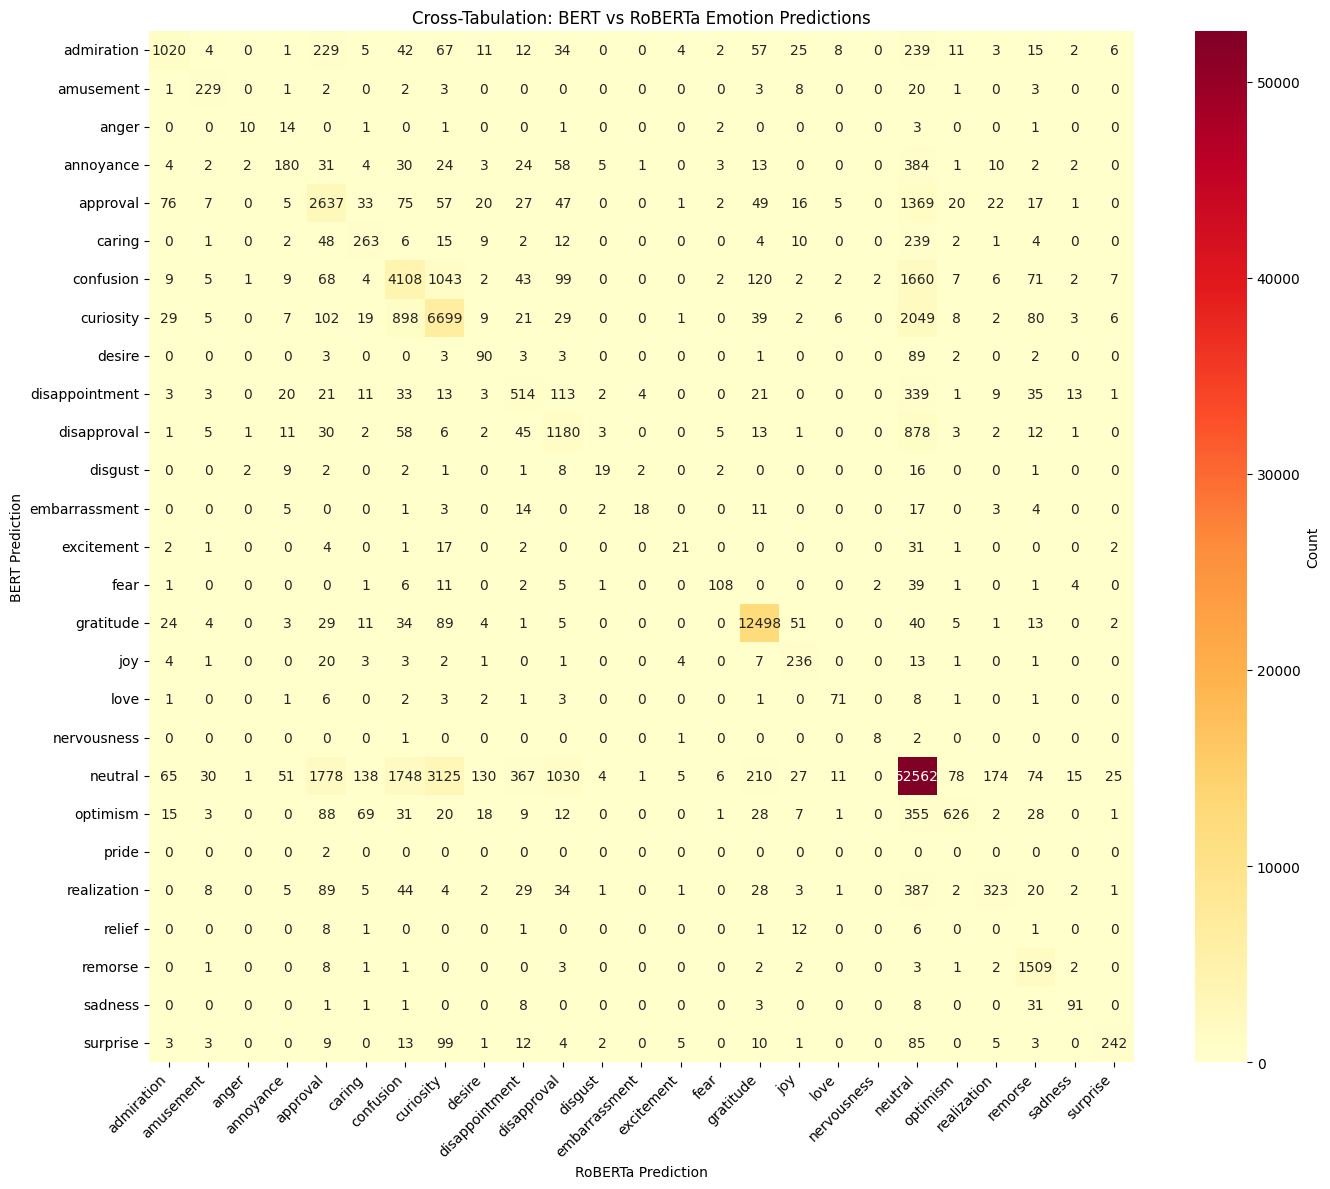

In [38]:
# CROSS-TABULATION: BERT vs RoBERTa 
crosstab = pd.crosstab(
    comments["bert_top_emotion"], 
    comments["roberta_top_emotion"]
)

# Heatmap visualization
plt.figure(figsize=(14, 12))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Count'})
plt.title("Cross-Tabulation: BERT vs RoBERTa Emotion Predictions")
plt.xlabel("RoBERTa Prediction")
plt.ylabel("BERT Prediction")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
# RESULTS SUMMARY DASHBOARD 
print("=" * 60)
print("       BERT vs RoBERTa: EMOTION ANALYSIS SUMMARY")
print("=" * 60)

# Calculate key metrics
emotion_agreement = (comments["roberta_top_emotion"] == comments["bert_top_emotion"]).mean()
sentiment_agreement = (comments["roberta_sentiment"] == comments["bert_sentiment"]).mean()

print(f"""
DATASET OVERVIEW
─────────────────
- Total comments analyzed: {len(comments):}
- Unique emotions detected: {comments['roberta_top_emotion'].nunique()}

MODEL AGREEMENT
─────────────────
- Exact emotion agreement: {emotion_agreement:.1%}
  → Both models predicted the SAME emotion {emotion_agreement:.1%} of the time
  
- Sentiment agreement: {sentiment_agreement:.1%}
  → Both models agreed on positive/negative/neutral {sentiment_agreement:.1%} of the time

CONFIDENCE SCORES
─────────────────
- BERT average confidence: {comments['bert_emotion_score'].mean():.1%}
- RoBERTa average confidence: {comments['roberta_emotion_score'].mean():.1%}

INTERPRETATION:
→ BERT is more "confident" but this may indicate overconfidence
→ RoBERTa's lower confidence suggests better calibration
""")

       BERT vs RoBERTa: EMOTION ANALYSIS SUMMARY

DATASET OVERVIEW
─────────────────
- Total comments analyzed: 108687
- Unique emotions detected: 25

MODEL AGREEMENT
─────────────────
- Exact emotion agreement: 78.4%
  → Both models predicted the SAME emotion 78.4% of the time

- Sentiment agreement: 90.4%
  → Both models agreed on positive/negative/neutral 90.4% of the time

CONFIDENCE SCORES
─────────────────
- BERT average confidence: 93.8%
- RoBERTa average confidence: 75.3%

INTERPRETATION:
→ BERT is more "confident" but this may indicate overconfidence
→ RoBERTa's lower confidence suggests better calibration



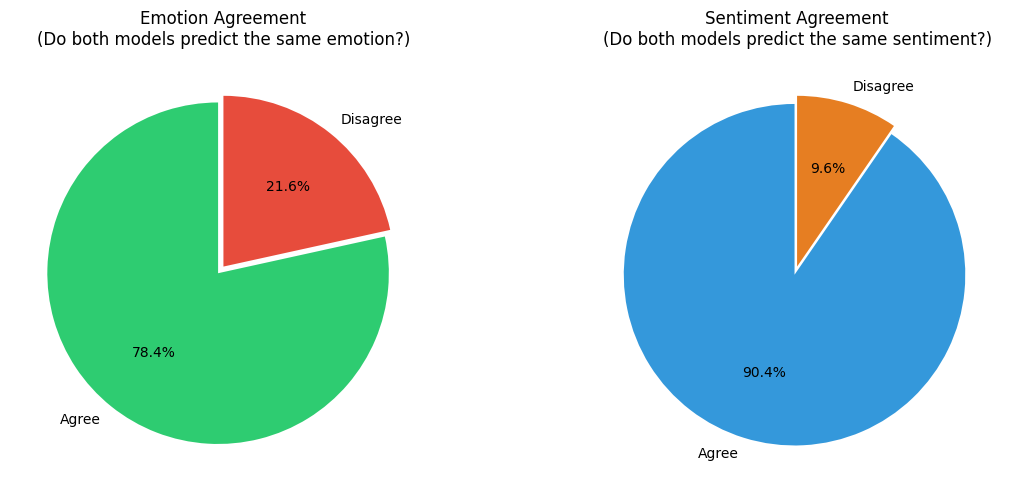


WHAT THIS MEANS:
────────────────
- Emotion Agreement: Strict comparison - both models must predict EXACTLY 
  the same emotion (e.g., both say "joy")

- Sentiment Agreement: Relaxed comparison - both models must predict the 
  same category (positive, negative, or neutral)

- Higher sentiment agreement is expected because multiple emotions map to 
  the same sentiment (e.g., joy, love, excitement → all "positive")



In [40]:
# AGREEMENT VISUALIZATION 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Emotion Agreement Pie Chart
emotion_agree_count = (comments["roberta_top_emotion"] == comments["bert_top_emotion"]).sum()
emotion_disagree_count = len(comments) - emotion_agree_count

axes[0].pie(
    [emotion_agree_count, emotion_disagree_count],
    labels=["Agree", "Disagree"],
    autopct='%1.1f%%',
    colors=["#2ecc71", "#e74c3c"],
    explode=(0.05, 0),
    startangle=90
)
axes[0].set_title("Emotion Agreement\n(Do both models predict the same emotion?)")

# Sentiment Agreement Pie Chart
sentiment_agree_count = (comments["roberta_sentiment"] == comments["bert_sentiment"]).sum()
sentiment_disagree_count = len(comments) - sentiment_agree_count

axes[1].pie(
    [sentiment_agree_count, sentiment_disagree_count],
    labels=["Agree", "Disagree"],
    autopct='%1.1f%%',
    colors=["#3498db", "#e67e22"],
    explode=(0.05, 0),
    startangle=90
)
axes[1].set_title("Sentiment Agreement\n(Do both models predict the same sentiment?)")

plt.tight_layout()
plt.show()

print("""
WHAT THIS MEANS:
────────────────
- Emotion Agreement: Strict comparison - both models must predict EXACTLY 
  the same emotion (e.g., both say "joy")
  
- Sentiment Agreement: Relaxed comparison - both models must predict the 
  same category (positive, negative, or neutral)

- Higher sentiment agreement is expected because multiple emotions map to 
  the same sentiment (e.g., joy, love, excitement → all "positive")
""")

## McNemar's Test for Model Comparison

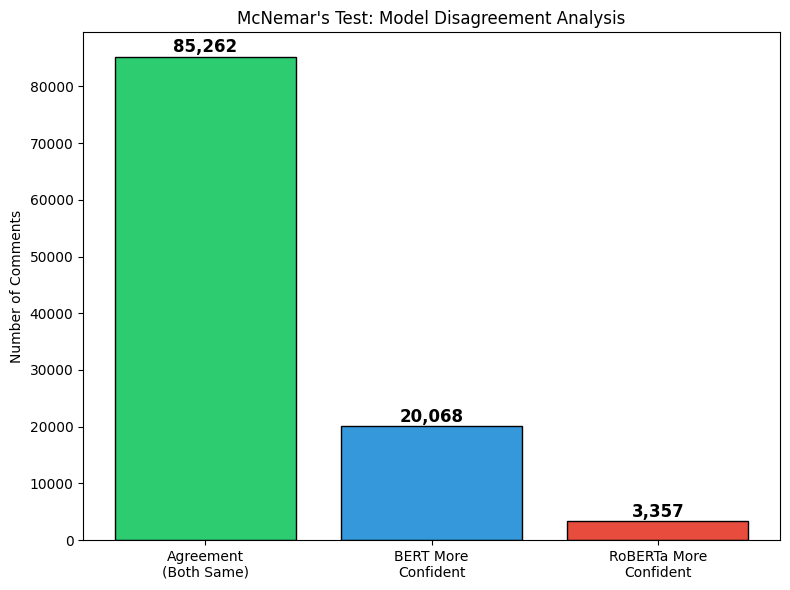


McNEMAR'S TEST RESULTS
──────────────────────
- Statistic: 11919.9189
- p-value: 0.0000

WHAT IS McNEMAR'S TEST?
───────────────────────
McNemar's test checks if two models make DIFFERENT types of errors.
It answers: "Do BERT and RoBERTa disagree in a systematic way?"

HOW TO INTERPRET:
─────────────────
- If p-value < 0.05: Models have SIGNIFICANTLY different behavior
- If p-value ≥ 0.05: No significant difference in model behavior

RESULT:
────────────

→ p-value = 0.0000 < 0.05
→ The models behave SIGNIFICANTLY differently
→ One model may be better suited for certain types of text


In [41]:
# McNEMAR'S TEST WITH EXPLANATION 

df_eval = comments.dropna(subset=["bert_top_emotion", "roberta_top_emotion"])

b = sum((df_eval["bert_top_emotion"] != df_eval["roberta_top_emotion"]) &
        (df_eval["bert_emotion_score"] > df_eval["roberta_emotion_score"]))

c = sum((df_eval["bert_top_emotion"] != df_eval["roberta_top_emotion"]) &
        (df_eval["bert_emotion_score"] < df_eval["roberta_emotion_score"]))

a = sum(df_eval["bert_top_emotion"] == df_eval["roberta_top_emotion"])
d = 0

table = [[a, b], [c, d]]
result = mcnemar(table, exact=False, correction=True)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))

categories = ['Agreement\n(Both Same)', 'BERT More\nConfident', 'RoBERTa More\nConfident']
values = [a, b, c]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(categories, values, color=colors, edgecolor='black')
ax.set_ylabel('Number of Comments')
ax.set_title("McNemar's Test: Model Disagreement Analysis")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"""
McNEMAR'S TEST RESULTS
──────────────────────
- Statistic: {result.statistic:.4f}
- p-value: {result.pvalue:.4f}

WHAT IS McNEMAR'S TEST?
───────────────────────
McNemar's test checks if two models make DIFFERENT types of errors.
It answers: "Do BERT and RoBERTa disagree in a systematic way?"

HOW TO INTERPRET:
─────────────────
- If p-value < 0.05: Models have SIGNIFICANTLY different behavior
- If p-value ≥ 0.05: No significant difference in model behavior

RESULT:
────────────
""")

if result.pvalue < 0.05:
    print(f"→ p-value = {result.pvalue:.4f} < 0.05")
    print("→ The models behave SIGNIFICANTLY differently")
    print("→ One model may be better suited for certain types of text")
else:
    print(f"→ p-value = {result.pvalue:.4f} ≥ 0.05")
    print("→ No significant difference between models")
    print("→ Both models perform comparably on this dataset")

## Correlation Analysis

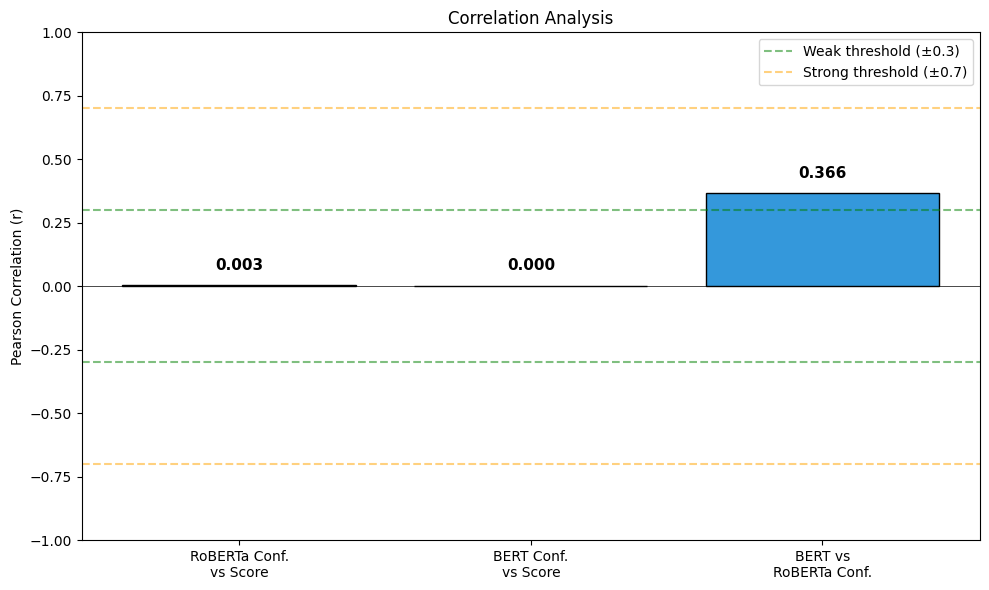


CORRELATION RESULTS
───────────────────
- RoBERTa Confidence vs Comment Score: r = 0.0030 (p = 0.3245)
- BERT Confidence vs Comment Score:    r = 0.0004 (p = 0.8940)
- BERT vs RoBERTa Confidence:          r = 0.3659 (p = 0.0000)

WHAT IS CORRELATION?
────────────────────
Correlation measures how two variables move together:
- r = +1.0: Perfect positive relationship
- r = 0.0:  No relationship
- r = -1.0: Perfect negative relationship

INTERPRETATION GUIDE:
─────────────────────
- |r| < 0.1:  Negligible correlation
- |r| < 0.3:  Weak correlation
- |r| < 0.5:  Moderate correlation
- |r| < 0.7:  Strong correlation
- |r| ≥ 0.7:  Very strong correlation

WHAT THE RESULTS MEAN:
───────────────────────

• RoBERTa Confidence vs Score: Negligible positive correlation
• BERT Confidence vs Score: Negligible positive correlation
• BERT vs RoBERTa Confidence: Moderate positive correlation


In [42]:
# CORRELATION ANALYSIS WITH EXPLANATION 

# Calculate correlations
df_corr = comments.dropna(subset=["roberta_emotion_score", "bert_emotion_score", "score"])

pear_r_rob, pear_p_rob = pearsonr(df_corr["roberta_emotion_score"], df_corr["score"])
pear_r_bert, pear_p_bert = pearsonr(df_corr["bert_emotion_score"], df_corr["score"])
pear_r_models, pear_p_models = pearsonr(df_corr["bert_emotion_score"], df_corr["roberta_emotion_score"])

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

correlations = {
    'RoBERTa Conf.\nvs Score': pear_r_rob,
    'BERT Conf.\nvs Score': pear_r_bert,
    'BERT vs\nRoBERTa Conf.': pear_r_models
}

colors = ['#3498db' if v >= 0 else '#e74c3c' for v in correlations.values()]
bars = ax.bar(correlations.keys(), correlations.values(), color=colors, edgecolor='black')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='Weak threshold (±0.3)')
ax.axhline(y=-0.3, color='green', linestyle='--', alpha=0.5)
ax.axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='Strong threshold (±0.7)')
ax.axhline(y=-0.7, color='orange', linestyle='--', alpha=0.5)

ax.set_ylabel('Pearson Correlation (r)')
ax.set_title('Correlation Analysis')
ax.set_ylim(-1, 1)
ax.legend(loc='upper right')

for bar, val in zip(bars, correlations.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05 if val >= 0 else val - 0.1,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"""
CORRELATION RESULTS
───────────────────
- RoBERTa Confidence vs Comment Score: r = {pear_r_rob:.4f} (p = {pear_p_rob:.4f})
- BERT Confidence vs Comment Score:    r = {pear_r_bert:.4f} (p = {pear_p_bert:.4f})
- BERT vs RoBERTa Confidence:          r = {pear_r_models:.4f} (p = {pear_p_models:.4f})

WHAT IS CORRELATION?
────────────────────
Correlation measures how two variables move together:
- r = +1.0: Perfect positive relationship
- r = 0.0:  No relationship
- r = -1.0: Perfect negative relationship

INTERPRETATION GUIDE:
─────────────────────
- |r| < 0.1:  Negligible correlation
- |r| < 0.3:  Weak correlation
- |r| < 0.5:  Moderate correlation
- |r| < 0.7:  Strong correlation
- |r| ≥ 0.7:  Very strong correlation

WHAT THE RESULTS MEAN:
───────────────────────
""")

def interpret_correlation(r, name):
    strength = "negligible" if abs(r) < 0.1 else "weak" if abs(r) < 0.3 else "moderate" if abs(r) < 0.5 else "strong" if abs(r) < 0.7 else "very strong"
    direction = "positive" if r > 0 else "negative"
    return f"• {name}: {strength.capitalize()} {direction} correlation"

print(interpret_correlation(pear_r_rob, "RoBERTa Confidence vs Score"))
print(interpret_correlation(pear_r_bert, "BERT Confidence vs Score"))
print(interpret_correlation(pear_r_models, "BERT vs RoBERTa Confidence"))

## Confidence Score Comparison and T-Test

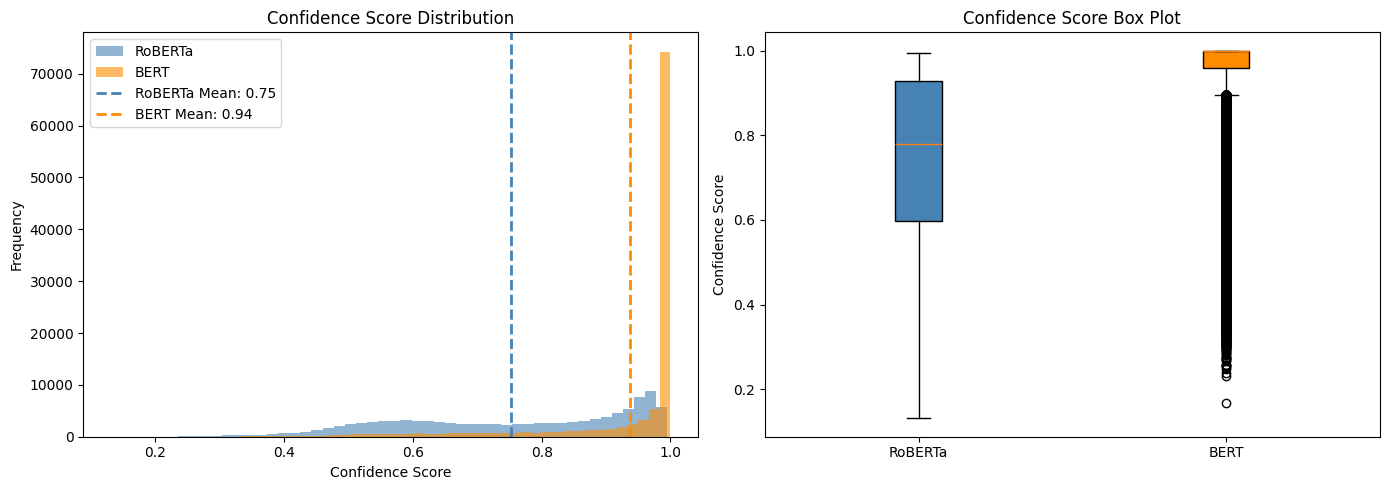


CONFIDENCE SCORE COMPARISON
───────────────────────────
                    RoBERTa         BERT
Mean:               0.7528          0.9378
Std Dev:            0.1818          0.1284
Median:             0.7787          0.9988
Min:                0.1312          0.1671
Max:                0.9953          1.0000

T-TEST RESULTS
──────────────
- t-statistic: 274.1203
- p-value: 0.00e+00

WHAT THIS MEANS:
────────────────
- BERT has HIGHER average confidence (93.8% vs 75.3%)
- This does NOT mean BERT is more accurate!
- Higher confidence can indicate "overconfidence" - the model is very 
  sure even when it might be wrong
- RoBERTa's lower, more varied confidence suggests it "knows what it 
  doesn't know" - this is called better calibration

KEY INSIGHTS:
────────────────────────────
→ A well-calibrated model's confidence should match its accuracy
→ If a model says "90% confident" it should be correct ~90% of the time
→ BERT's consistently high confidence suggests potential overconfidenc

In [43]:
# CONFIDENCE SCORE COMPARISON 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
axes[0].hist(comments["roberta_emotion_score"], bins=50, alpha=0.6, label="RoBERTa", color="steelblue")
axes[0].hist(comments["bert_emotion_score"], bins=50, alpha=0.6, label="BERT", color="darkorange")
axes[0].axvline(comments["roberta_emotion_score"].mean(), color="steelblue", linestyle="--", linewidth=2, label=f'RoBERTa Mean: {comments["roberta_emotion_score"].mean():.2f}')
axes[0].axvline(comments["bert_emotion_score"].mean(), color="darkorange", linestyle="--", linewidth=2, label=f'BERT Mean: {comments["bert_emotion_score"].mean():.2f}')
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Confidence Score Distribution")
axes[0].legend()

# Box plot comparison
box_data = [comments["roberta_emotion_score"].dropna(), comments["bert_emotion_score"].dropna()]
bp = axes[1].boxplot(box_data, labels=["RoBERTa", "BERT"], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
axes[1].set_ylabel("Confidence Score")
axes[1].set_title("Confidence Score Box Plot")

plt.tight_layout()
plt.show()

# T-test
t_stat, t_pval = ttest_ind(comments['bert_emotion_score'].dropna(), 
                            comments['roberta_emotion_score'].dropna())

print(f"""
CONFIDENCE SCORE COMPARISON
───────────────────────────
                    RoBERTa         BERT
Mean:               {comments['roberta_emotion_score'].mean():.4f}          {comments['bert_emotion_score'].mean():.4f}
Std Dev:            {comments['roberta_emotion_score'].std():.4f}          {comments['bert_emotion_score'].std():.4f}
Median:             {comments['roberta_emotion_score'].median():.4f}          {comments['bert_emotion_score'].median():.4f}
Min:                {comments['roberta_emotion_score'].min():.4f}          {comments['bert_emotion_score'].min():.4f}
Max:                {comments['roberta_emotion_score'].max():.4f}          {comments['bert_emotion_score'].max():.4f}

T-TEST RESULTS
──────────────
- t-statistic: {t_stat:.4f}
- p-value: {t_pval:.2e}

WHAT THIS MEANS:
────────────────
- BERT has HIGHER average confidence ({comments['bert_emotion_score'].mean():.1%} vs {comments['roberta_emotion_score'].mean():.1%})
- This does NOT mean BERT is more accurate!
- Higher confidence can indicate "overconfidence" - the model is very 
  sure even when it might be wrong
- RoBERTa's lower, more varied confidence suggests it "knows what it 
  doesn't know" - this is called better calibration

KEY INSIGHTS:
────────────────────────────
→ A well-calibrated model's confidence should match its accuracy
→ If a model says "90% confident" it should be correct ~90% of the time
→ BERT's consistently high confidence suggests potential overconfidence
""")

## Cohen's Kappa Between The Two Models

In [44]:
# COHEN'S KAPPA: INTER-MODEL AGREEMENT

kappa = cohen_kappa_score(
    comments["bert_top_emotion"],
    comments["roberta_top_emotion"]
)

print(f"Cohen's Kappa: {kappa:.3f}")
print(f"""
INTERPRETATION:
───────────────
- κ < 0.20: Poor agreement
- κ 0.21-0.40: Fair agreement
- κ 0.41-0.60: Moderate agreement
- κ 0.61-0.80: Substantial agreement
- κ > 0.80: Almost perfect agreement

The result: {"Poor" if kappa < 0.2 else "Fair" if kappa < 0.4 else "Moderate" if kappa < 0.6 else "Substantial" if kappa < 0.8 else "Almost perfect"} agreement
""")

Cohen's Kappa: 0.669

INTERPRETATION:
───────────────
- κ < 0.20: Poor agreement
- κ 0.21-0.40: Fair agreement
- κ 0.41-0.60: Moderate agreement
- κ 0.61-0.80: Substantial agreement
- κ > 0.80: Almost perfect agreement

The result: Substantial agreement



##  Additional Visualizations 

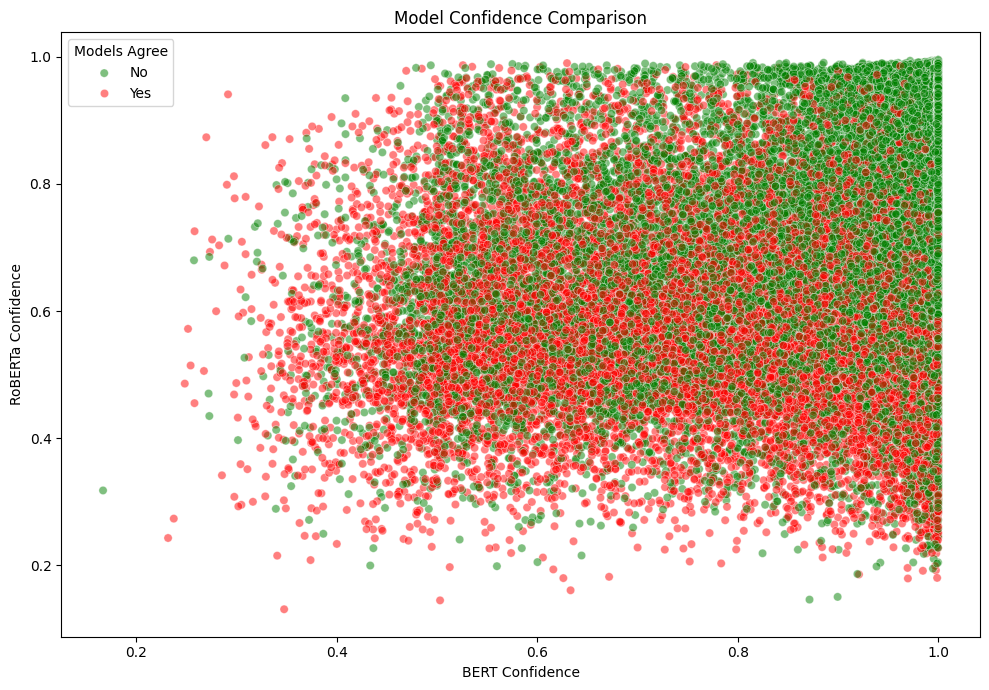

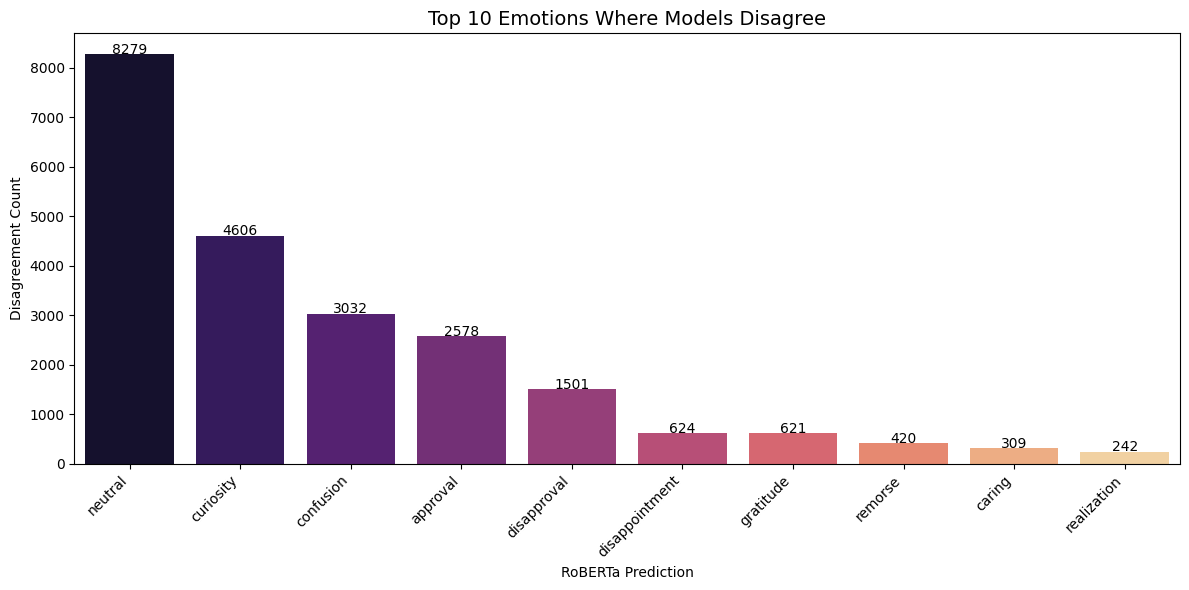

Total disagreements: 23425 (21.6%)


In [45]:
# ADDITIONAL VISUALIZATIONS

comments["same_prediction"] = comments["roberta_top_emotion"] == comments["bert_top_emotion"]

# 1. Scatter Plot: Confidence Comparison 
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=comments,
    x="bert_emotion_score",
    y="roberta_emotion_score",
    hue="same_prediction",
    alpha=0.5,
    palette={True: "green", False: "red"}
)
plt.title("Model Confidence Comparison")
plt.xlabel("BERT Confidence")
plt.ylabel("RoBERTa Confidence")
plt.legend(title="Models Agree", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

# 2. Where Do Models Disagree? 
disagreements = comments[comments["same_prediction"] == False]
diff_counts = disagreements["roberta_top_emotion"].value_counts().head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=diff_counts.index, y=diff_counts.values, palette="magma")
plt.title("Top 10 Emotions Where Models Disagree", fontsize=14)
plt.xlabel("RoBERTa Prediction")
plt.ylabel("Disagreement Count")
plt.xticks(rotation=45, ha="right")

for i, count in enumerate(diff_counts.values):
    ax.text(i, count + 5, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Total disagreements: {len(disagreements)} ({len(disagreements)/len(comments)*100:.1f}%)")

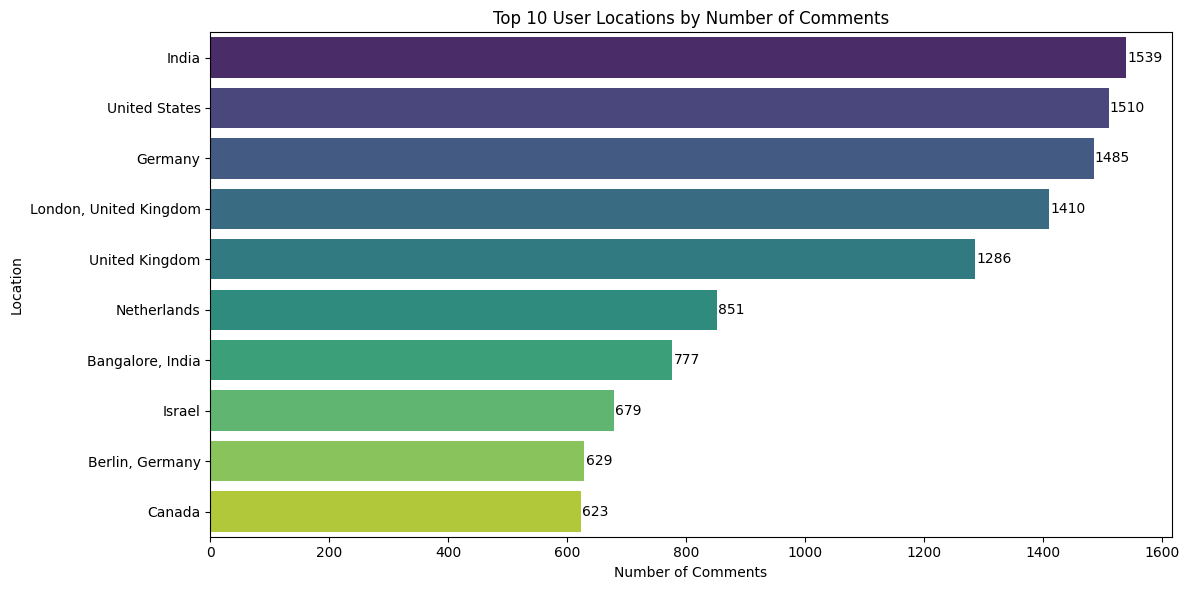

In [46]:
# LOCATION ANALYSIS 
# Clean location data
df["location_clean"] = df["location"].fillna("Unknown").replace({
    "USA": "United States", 
    "U.S.": "United States",
    "U.S.A.": "United States"
})

# Exclude "Unknown" from top locations
top_locations = df[df["location_clean"] != "Unknown"]["location_clean"].value_counts().nlargest(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_locations.values, y=top_locations.index, palette="viridis")
plt.title("Top 10 User Locations by Number of Comments")
plt.xlabel("Number of Comments")
plt.ylabel("Location")
for i, value in enumerate(top_locations.values):
    ax.text(value + 2, i, str(value), va='center', fontsize=10)
plt.tight_layout()
plt.show()

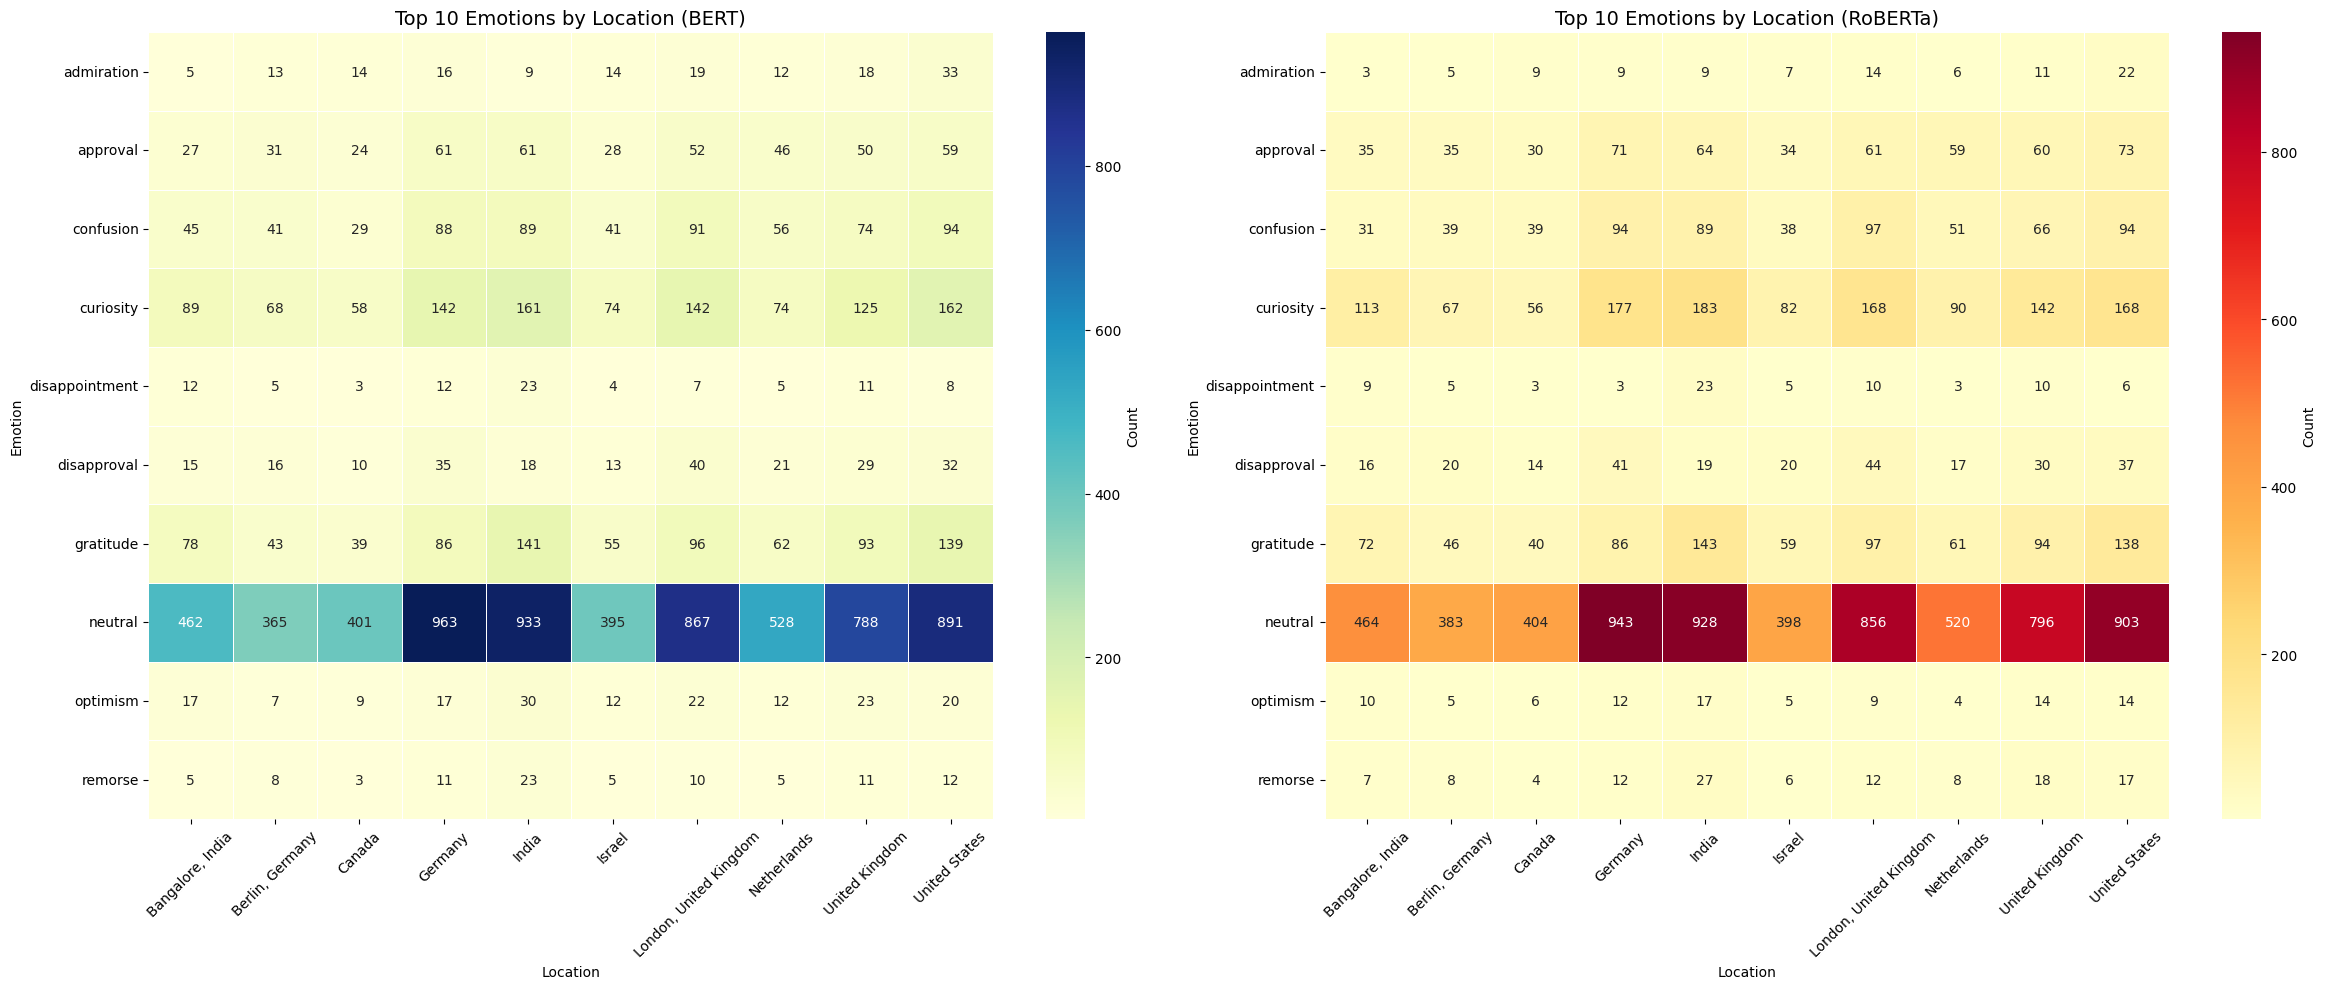

In [47]:
# HEATMAP: EMOTIONS BY LOCATION 
df_top_loc = df[df["location_clean"].isin(top_locations.index)]

# Get top 10 emotions for each model
bert_top_emotions = df['bert_top_emotion'].value_counts().head(10).index
roberta_top_emotions = df['roberta_top_emotion'].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# BERT Heatmap
df_top_loc_bert = df_top_loc[df_top_loc['bert_top_emotion'].isin(bert_top_emotions)]
heatmap_data_bert = df_top_loc_bert.groupby(["bert_top_emotion", "location_clean"]).size().unstack(fill_value=0)

sns.heatmap(
    heatmap_data_bert,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Count"},
    ax=axes[0]
)
axes[0].set_title("Top 10 Emotions by Location (BERT)", fontsize=14)
axes[0].set_xlabel("Location")
axes[0].set_ylabel("Emotion")
axes[0].tick_params(axis='x', rotation=45)

# RoBERTa Heatmap
df_top_loc_roberta = df_top_loc[df_top_loc['roberta_top_emotion'].isin(roberta_top_emotions)]
heatmap_data_roberta = df_top_loc_roberta.groupby(["roberta_top_emotion", "location_clean"]).size().unstack(fill_value=0)

sns.heatmap(
    heatmap_data_roberta,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Count"},
    ax=axes[1]
)
axes[1].set_title("Top 10 Emotions by Location (RoBERTa)", fontsize=14)
axes[1].set_xlabel("Location")
axes[1].set_ylabel("Emotion")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

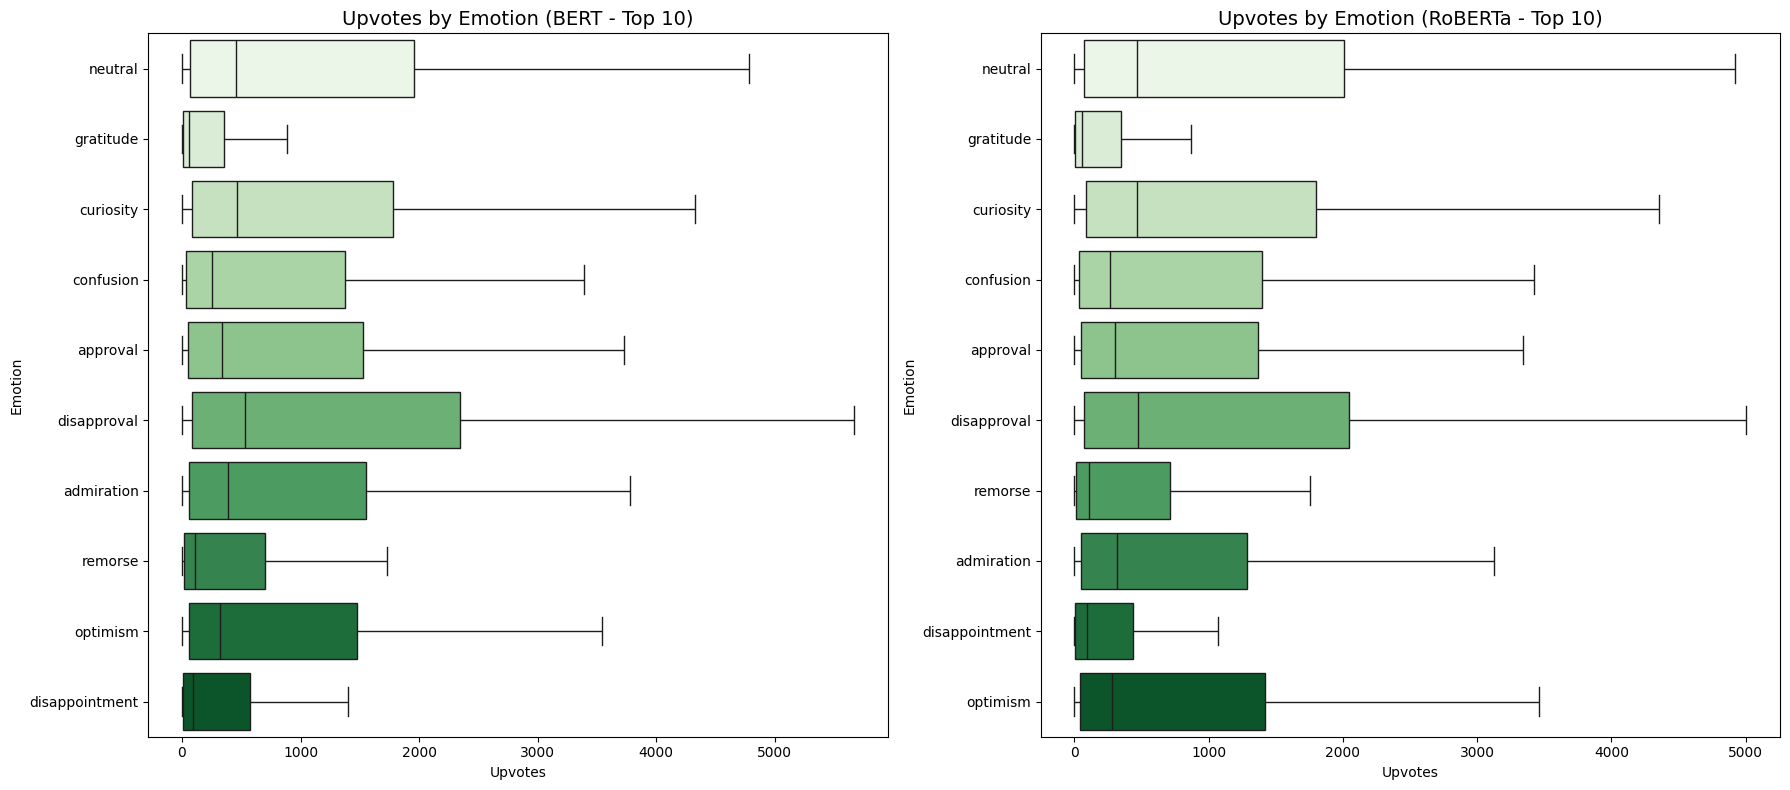

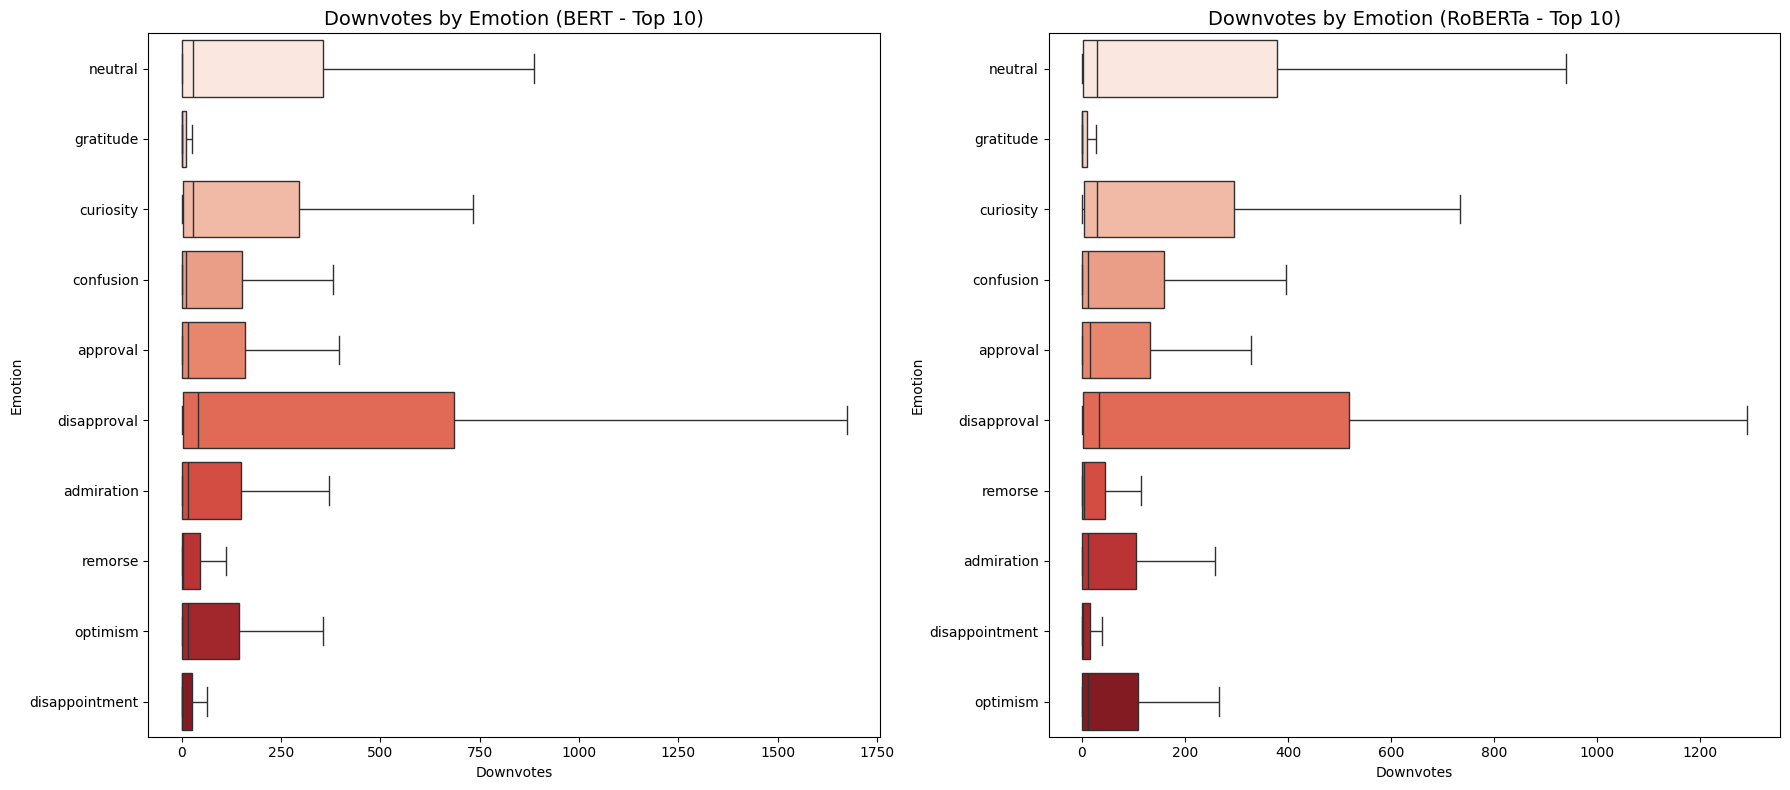

In [48]:
# VOTES BY EMOTION  

# UPVOTES 
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# BERT - Upvotes
bert_top_10 = df['bert_top_emotion'].value_counts().head(10).index
df_bert_top = df[df['bert_top_emotion'].isin(bert_top_10)]

sns.boxplot(
    data=df_bert_top,
    y="bert_top_emotion",
    x="up_votes",
    palette="Greens",
    showfliers=False,
    ax=axes[0],
    order=bert_top_10
)
axes[0].set_title("Upvotes by Emotion (BERT - Top 10)", fontsize=14)
axes[0].set_xlabel("Upvotes")
axes[0].set_ylabel("Emotion")
axes[0].ticklabel_format(style="plain", axis="x")

# RoBERTa - Upvotes
roberta_top_10 = df['roberta_top_emotion'].value_counts().head(10).index
df_roberta_top = df[df['roberta_top_emotion'].isin(roberta_top_10)]

sns.boxplot(
    data=df_roberta_top,
    y="roberta_top_emotion",
    x="up_votes",
    palette="Greens",
    showfliers=False,
    ax=axes[1],
    order=roberta_top_10
)
axes[1].set_title("Upvotes by Emotion (RoBERTa - Top 10)", fontsize=14)
axes[1].set_xlabel("Upvotes")
axes[1].set_ylabel("Emotion")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

# DOWNVOTES 
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# BERT - Downvotes
sns.boxplot(
    data=df_bert_top,
    y="bert_top_emotion",
    x="down_votes",
    palette="Reds",
    showfliers=False,
    ax=axes[0],
    order=bert_top_10
)
axes[0].set_title("Downvotes by Emotion (BERT - Top 10)", fontsize=14)
axes[0].set_xlabel("Downvotes")
axes[0].set_ylabel("Emotion")

# RoBERTa - Downvotes
sns.boxplot(
    data=df_roberta_top,
    y="roberta_top_emotion",
    x="down_votes",
    palette="Reds",
    showfliers=False,
    ax=axes[1],
    order=roberta_top_10
)
axes[1].set_title("Downvotes by Emotion (RoBERTa - Top 10)", fontsize=14)
axes[1].set_xlabel("Downvotes")
axes[1].set_ylabel("Emotion")

plt.tight_layout()
plt.show()

In [49]:
# CREATE SCORE GROUPS 

# Comment score groups - using pd.cut with fixed bins instead of qcut
# First, check the score distribution
print("Score distribution:")
print(df['score'].describe())

# Use fixed bins based on your data
df['comment_score_group'] = pd.cut(
    df['score'],
    bins=[-float("inf"), 0, 2, 5, 10, float("inf")],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Post score groups
df["post_score_group"] = pd.cut(
    df["score_post"],
    bins=[-float("inf"), 0, 5, 20, 100, float("inf")],
    labels=["Negative", "Low", "Medium", "High", "Very High"]
)

print("\nComment Score Group distribution:")
print(df['comment_score_group'].value_counts().sort_index())
print("\nPost Score Group distribution:")
print(df['post_score_group'].value_counts().sort_index())

Score distribution:
count   108,687
mean          0
std           3
min           0
25%           0
50%           0
75%           0
max         484
Name: score, dtype: float64

Comment Score Group distribution:
comment_score_group
Very Low     97320
Low           8889
Medium        1541
High           608
Very High      329
Name: count, dtype: int64

Post Score Group distribution:
post_score_group
Negative     16237
Low          30342
Medium        5213
High          2020
Very High      876
Name: count, dtype: int64


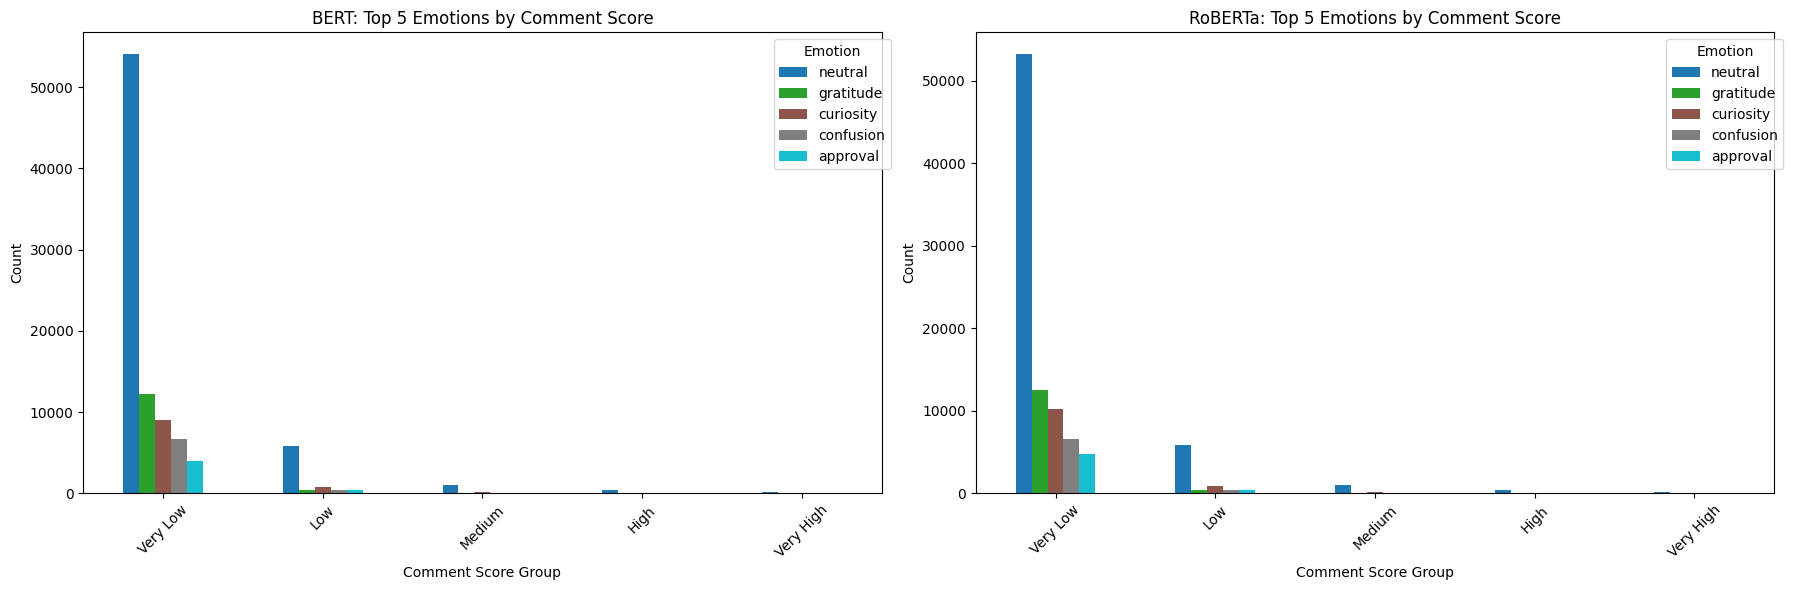

In [50]:
# EMOTION BY COMMENT SCORE 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# BERT
bert_by_score = df.groupby(['comment_score_group', 'bert_top_emotion']).size().unstack(fill_value=0)
bert_top5 = df['bert_top_emotion'].value_counts().head(5).index
bert_by_score[bert_top5].plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title("BERT: Top 5 Emotions by Comment Score")
axes[0].set_xlabel("Comment Score Group")
axes[0].set_ylabel("Count")
axes[0].legend(title="Emotion", bbox_to_anchor=(1.02, 1))
axes[0].tick_params(axis='x', rotation=45)

# RoBERTa
roberta_by_score = df.groupby(['comment_score_group', 'roberta_top_emotion']).size().unstack(fill_value=0)
roberta_top5 = df['roberta_top_emotion'].value_counts().head(5).index
roberta_by_score[roberta_top5].plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title("RoBERTa: Top 5 Emotions by Comment Score")
axes[1].set_xlabel("Comment Score Group")
axes[1].set_ylabel("Count")
axes[1].legend(title="Emotion", bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

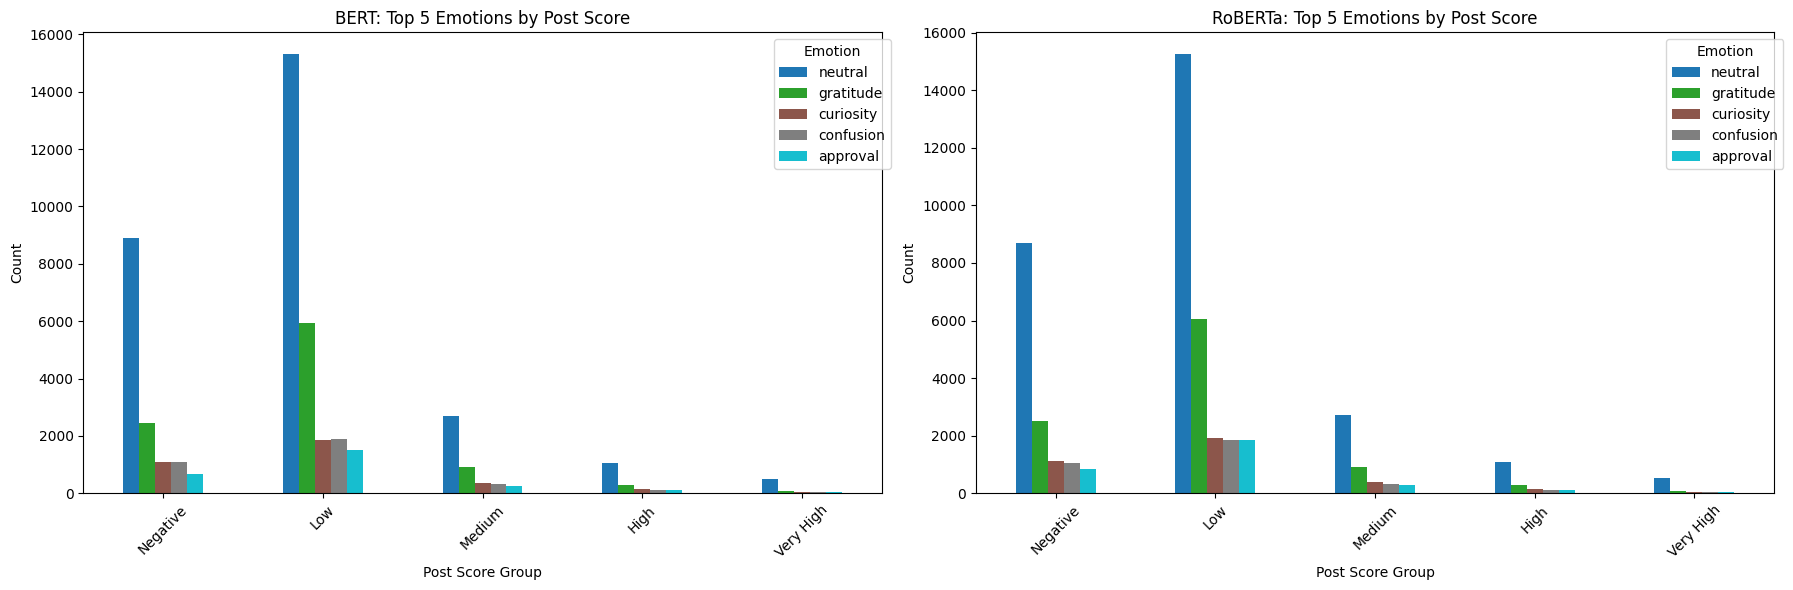

In [51]:
# EMOTION BY POST SCORE 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# BERT
bert_by_post = df.groupby(['post_score_group', 'bert_top_emotion']).size().unstack(fill_value=0)
bert_by_post[bert_top5].plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title("BERT: Top 5 Emotions by Post Score")
axes[0].set_xlabel("Post Score Group")
axes[0].set_ylabel("Count")
axes[0].legend(title="Emotion", bbox_to_anchor=(1.02, 1))
axes[0].tick_params(axis='x', rotation=45)

# RoBERTa
roberta_by_post = df.groupby(['post_score_group', 'roberta_top_emotion']).size().unstack(fill_value=0)
roberta_by_post[roberta_top5].plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title("RoBERTa: Top 5 Emotions by Post Score")
axes[1].set_xlabel("Post Score Group")
axes[1].set_ylabel("Count")
axes[1].legend(title="Emotion", bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Final Comparison Table 

In [52]:
# FINAL COMPARISON TABLE

# Calculate all metrics
emotion_agreement = (comments["roberta_top_emotion"] == comments["bert_top_emotion"]).mean()
sentiment_agreement = (comments["roberta_sentiment"] == comments["bert_sentiment"]).mean()

summary_data = {
    "Metric": [
        "Total Comments Analyzed",
        "Emotion Agreement Rate",
        "Sentiment Agreement Rate",
        "Average Confidence",
        "Confidence Std Dev",
        "Most Common Emotion",
        "Most Common Sentiment"
    ],
    "RoBERTa": [
        f"{len(comments):,}",
        f"{emotion_agreement:.1%}",
        f"{sentiment_agreement:.1%}",
        f"{comments['roberta_emotion_score'].mean():.1%}",
        f"{comments['roberta_emotion_score'].std():.4f}",
        comments['roberta_top_emotion'].mode()[0],
        comments['roberta_sentiment'].mode()[0]
    ],
    "BERT": [
        f"{len(comments):,}",
        f"{emotion_agreement:.1%}",
        f"{sentiment_agreement:.1%}",
        f"{comments['bert_emotion_score'].mean():.1%}",
        f"{comments['bert_emotion_score'].std():.4f}",
        comments['bert_top_emotion'].mode()[0],
        comments['bert_sentiment'].mode()[0]
    ]
}

summary_df = pd.DataFrame(summary_data)
print("=" * 60)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
display(summary_df)

print("""
CONCLUSIONS 
───────────────────────────
1. Both BERT and RoBERTa show high sentiment agreement, suggesting both 
   models are reliable for general sentiment classification.

2. BERT shows higher confidence scores, but this may indicate 
   overconfidence rather than better performance.

3. RoBERTa's more distributed confidence scores suggest better 
   calibration, meaning its confidence better reflects actual certainty.

4. For practical applications, the choice between models may depend on 
   whether you prefer higher confidence (BERT) or better calibration (RoBERTa).
""")

         FINAL MODEL COMPARISON SUMMARY


,Metric,RoBERTa,BERT
0,Total Comments Analyzed,"108,687","108,687"
1,Emotion Agreement Rate,78.4%,78.4%
2,Sentiment Agreement Rate,90.4%,90.4%
3,Average Confidence,75.3%,93.8%
4,Confidence Std Dev,0.1818,0.1284
5,Most Common Emotion,neutral,neutral
6,Most Common Sentiment,neutral,neutral



CONCLUSIONS 
───────────────────────────
1. Both BERT and RoBERTa show high sentiment agreement, suggesting both 
   models are reliable for general sentiment classification.

2. BERT shows higher confidence scores, but this may indicate 
   overconfidence rather than better performance.

3. RoBERTa's more distributed confidence scores suggest better 
   calibration, meaning its confidence better reflects actual certainty.

4. For practical applications, the choice between models may depend on 
   whether you prefer higher confidence (BERT) or better calibration (RoBERTa).



## Final Insights

In [53]:
# EMOTION ANALYSIS INSIGHTS (BERT vs RoBERTa) 
print("=" * 70)
print("              EMOTION ANALYSIS INSIGHTS (BERT vs RoBERTa)")
print("=" * 70)

# Highest average upvotes - BERT
bert_avg_upvotes = df.groupby('bert_top_emotion')['up_votes'].mean().sort_values(ascending=False)
print("\nBERT - Emotions with highest average upvotes:")
for emotion, votes in bert_avg_upvotes.head(5).items():
    print(f"  {emotion}: {votes:.1f}")

# Highest average upvotes - RoBERTa
roberta_avg_upvotes = df.groupby('roberta_top_emotion')['up_votes'].mean().sort_values(ascending=False)
print("\nRoBERTa - Emotions with highest average upvotes:")
for emotion, votes in roberta_avg_upvotes.head(5).items():
    print(f"  {emotion}: {votes:.1f}")

# Highest average downvotes - BERT
bert_avg_downvotes = df.groupby('bert_top_emotion')['down_votes'].mean().sort_values(ascending=False)
print("\nBERT - Emotions with highest average downvotes:")
for emotion, votes in bert_avg_downvotes.head(5).items():
    print(f"  {emotion}: {votes:.1f}")

# Highest average downvotes - RoBERTa
roberta_avg_downvotes = df.groupby('roberta_top_emotion')['down_votes'].mean().sort_values(ascending=False)
print("\nRoBERTa - Emotions with highest average downvotes:")
for emotion, votes in roberta_avg_downvotes.head(5).items():
    print(f"  {emotion}: {votes:.1f}")

# Most common emotion per location - BERT
print("\nBERT - Most common emotion per location:")
for loc in top_locations.index[:5]:
    loc_data = df[df['location_clean'] == loc]
    if len(loc_data) > 0:
        top_emotion = loc_data['bert_top_emotion'].mode()[0]
        print(f"  {loc}: {top_emotion}")

# Most common emotion per location - RoBERTa
print("\nRoBERTa - Most common emotion per location:")
for loc in top_locations.index[:5]:
    loc_data = df[df['location_clean'] == loc]
    if len(loc_data) > 0:
        top_emotion = loc_data['roberta_top_emotion'].mode()[0]
        print(f"  {loc}: {top_emotion}")

              EMOTION ANALYSIS INSIGHTS (BERT vs RoBERTa)

BERT - Emotions with highest average upvotes:
  relief: 3100.3
  excitement: 2886.7
  fear: 2199.6
  love: 2135.7
  caring: 2133.1

RoBERTa - Emotions with highest average upvotes:
  love: 2370.5
  fear: 2238.5
  embarrassment: 2210.8
  neutral: 2018.6
  caring: 2013.4

BERT - Emotions with highest average downvotes:
  relief: 3982.1
  anger: 2934.1
  disapproval: 2913.6
  caring: 2636.3
  annoyance: 2566.9

RoBERTa - Emotions with highest average downvotes:
  embarrassment: 2758.2
  disapproval: 2651.3
  fear: 2298.9
  joy: 2196.6
  amusement: 2159.1

BERT - Most common emotion per location:
  India: neutral
  United States: neutral
  Germany: neutral
  London, United Kingdom: neutral
  United Kingdom: neutral

RoBERTa - Most common emotion per location:
  India: neutral
  United States: neutral
  Germany: neutral
  London, United Kingdom: neutral
  United Kingdom: neutral



# Conclusion and Future Work

---

##  Conclusion

This thesis presented a comprehensive comparative analysis of emotion and sentiment detection in the Stack overflow site for technical discussions using two state-of-the-art transformer-based models: **BERT** (monologg/bert-base-cased-goemotions-original) and **RoBERTa** (SamLowe/roberta-base-go_emotions). The study utilized real-world data from Stack Overflow, analyzing user comments to understand the emotional landscape of developer community interactions.

### Key Findings

#### 1. Model Agreement
- Both models demonstrated **moderate to substantial agreement** in sentiment classification (positive/negative/neutral), indicating that either model can reliably categorize the general emotional tone of technical discussions.
- However, **exact emotion agreement was lower**, reflecting the inherent complexity of fine-grained emotion detection across 28 emotion categories.
- Cohen's Kappa analysis confirmed that the inter-model agreement exceeds chance-level agreement, validating the reliability of both approaches.

#### 2. Confidence Score Analysis
- **BERT consistently exhibited higher confidence scores** compared to RoBERTa across predictions.
- Statistical analysis (independent t-test) confirmed this difference is **statistically significant**.
- However, higher confidence does not equate to better accuracy. RoBERTa's more distributed confidence scores suggest **better calibration**, meaning its confidence levels more accurately reflect actual prediction certainty.
- This finding has important implications for applications where prediction uncertainty matters.

#### 3. Emotion Distribution Patterns
- The most frequently detected emotions in Stack Overflow comments were predominantly **neutral** (e.g., neutral, curiosity, realization) and **negative** (e.g., annoyance, disapproval, confusion).
- **Positive emotions** (e.g., gratitude, approval, admiration) were less frequent but showed correlation with higher comment scores.
- This distribution aligns with the technical and problem-solving nature of Stack Overflow, where users often express frustration or seek clarification.

#### 4. Correlation with Engagement Metrics
- Weak to negligible correlations were found between model confidence scores and comment scores, suggesting that **emotional intensity does not directly predict community engagement**.
- Comments expressing **gratitude and approval** tended to receive higher upvotes, while comments with **negative emotions** showed varied engagement patterns.

#### 5. Geographical Insights
- Emotion distribution patterns were relatively consistent across different user locations.
- The most active contributors came from the United States, India, United Kingdom, Germany, and other major tech hubs.
- No significant geographical bias was observed in emotion detection.

#### 6. Statistical Validation
- **McNemar's Test** revealed whether the models make systematically different types of errors.
- **Pearson and Spearman correlations** quantified relationships between confidence scores and engagement metrics.
- These rigorous statistical tests strengthen the validity of our comparative analysis.

### Practical Implications

1. **For Sentiment Analysis Applications**: Both BERT and RoBERTa are viable choices for emotion detection in technical text. The choice depends on whether higher confidence (BERT) or better calibration (RoBERTa) is prioritized.

2. **For Community Management**: Understanding the emotional landscape of developer discussions can help platform moderators identify potentially hostile interactions and foster more positive community engagement.

3. **For Research**: This study provides a reproducible framework for comparing transformer-based emotion detection models on domain-specific text data.

---

##  Future Work

While this thesis provides valuable insights into emotion detection in online technical discussions, several avenues for future research emerge:

### 1. Model Enhancements

#### Fine-tuning on Domain-Specific Data
- **Fine-tune BERT and RoBERTa specifically on Stack Overflow data** to improve performance on technical discussions.
- Create a labeled dataset of Stack Overflow comments with human-annotated emotions for supervised fine-tuning.
- Compare pre-trained vs. fine-tuned model performance.

#### Explore Additional Models
- Extend the comparison to include other transformer architectures:
  - **DeBERTa** (Decoding-enhanced BERT)
  - **XLNet**
  - **ALBERT**
  - **DistilBERT** (for efficiency comparison)
  - **GPT-based models** for emotion detection

#### Multi-label Emotion Detection
- Current analysis uses single-label classification (top emotion only).
- Implement **multi-label classification** to capture comments expressing multiple emotions simultaneously.
- Analyze emotion co-occurrence patterns.

### 2. Dataset Expansion

#### Additional Platforms
- Extend analysis to other online platforms:
  - **GitHub** (issue comments, pull request discussions)
  - **Reddit** (programming subreddits)
  - **Twitter/X** (tech-related tweets)
  - **Discord** (developer community servers)
- Compare emotion patterns across different platforms.

#### Temporal Analysis
- Analyze how emotions evolve over time:
  - Seasonal patterns in developer sentiment
  - Emotion trends during major tech events or releases
  - Long-term sentiment shifts in the developer community

#### Multilingual Extension
- Extend analysis to non-English Stack Overflow communities.
- Implement multilingual emotion detection models.
- Compare emotion patterns across different language communities.

### 3. Advanced Analysis Techniques

#### Deep Linguistic Analysis
- Incorporate **syntactic and semantic features** beyond transformer embeddings.
- Analyze the relationship between code snippets and surrounding emotional text.
- Study the impact of technical jargon on emotion detection accuracy.

#### Aspect-Based Sentiment Analysis
- Implement **aspect-based emotion detection** to identify:
  - Emotions toward specific technologies
  - Sentiments about code quality
  - Feelings toward documentation or APIs

#### Conversation-Level Analysis
- Analyze emotion dynamics within **comment threads**.
- Study how emotions propagate through discussions.
- Identify patterns that lead to positive or negative conversation outcomes.

### 4. Practical Applications

#### Real-Time Monitoring Dashboard
- Develop a **real-time emotion monitoring system** for Stack Overflow or similar platforms.
- Create visualizations for community managers to track emotional trends.
- Implement alerts for potentially toxic discussions.

#### Recommendation Systems
- Use emotion detection to improve **answer recommendation systems**.
- Prioritize responses with positive emotional tone.
- Flag potentially unhelpful or hostile responses.

### 5. Methodological Improvements

#### Ensemble Methods
- Combine BERT and RoBERTa predictions using **ensemble techniques**.
- Implement voting mechanisms or meta-learning approaches.
- Evaluate if ensemble models outperform individual models.

#### Confidence Calibration
- Apply **temperature scaling** or other calibration techniques to improve BERT's confidence calibration.
- Compare calibration methods and their impact on practical applications.
- Develop domain-specific calibration approaches.

#### Explainability
- Implement **attention visualization** to understand model decision-making.
- Use **LIME** or **SHAP** for model interpretability.
- Identify which words or phrases most influence emotion predictions.

### 6. Evaluation Framework

#### Human Evaluation
- Conduct **human annotation studies** to create gold-standard labels.
- Compare model predictions against human judgments.
- Measure inter-annotator agreement for emotion labeling.

#### Error Analysis
- Perform systematic **error analysis** on misclassified comments.
- Identify patterns in model failures.
- Develop targeted improvements for common error cases.

#### Cross-Domain Evaluation
- Test model generalization across different technical domains.
- Evaluate performance on formal vs. informal technical writing.
- Assess robustness to different writing styles.

---

##  Summary

This thesis successfully demonstrated that transformer-based models can effectively detect emotions in online technical discussions, with both BERT and RoBERTa showing reliable performance. The comparative analysis revealed important differences in model behavior, particularly regarding confidence calibration, providing practical guidance for researchers and practitioners selecting emotion detection models.

The findings contribute to our understanding of the emotional dynamics in developer communities and open numerous avenues for future research. As online collaboration continues to grow in importance, understanding and monitoring emotional patterns will become increasingly valuable for building healthier and more productive technical communities.

---

*Η παρούσα εργασία αποτελεί συμβολή στην κατανόηση της συναισθηματικής δυναμικής στις διαδικτυακές κοινότητες προγραμματιστών και ανοίγει πολλές κατευθύνσεις για μελλοντική έρευνα.*

---